# Library Imports

In [1]:
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime
from functools import partial
import gc
import glob
import itertools
from itertools import combinations
import json
import math  
import networkx as nx
import numpy as np 
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
from pathlib import Path
import pandas as pd 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None) 
from pprint import pprint
import pyarrow as pa
import pyarrow.parquet as pq
import random
import re
import shutil
import statsmodels.api as sm
import string
import sys 
from tqdm import tqdm
from typing import Any, Dict, List, Optional

# Plots
from collections import Counter
from IPython.display import Image, display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.graph_objs as go
import plotly.io as pio
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Data Transformation 
from sklearn import set_config
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, MultiLabelBinarizer
from sklearn.compose import make_column_transformer, make_column_selector, ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Target Distribution 
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.utils.class_weight import compute_class_weight

# Feature Selection
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import shap
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer 
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif, mutual_info_regression, SelectKBest, SelectFwe, VarianceThreshold
from sklearn.impute import KNNImputer, MissingIndicator, SimpleImputer, IterativeImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import BayesianRidge

# Validation + Hyperparameters Tuning
from sklearn.model_selection import cross_validate, cross_val_score, GridSearchCV, KFold, LeaveOneOut, ParameterGrid, StratifiedKFold, TimeSeriesSplit, train_test_split
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_contour, plot_intermediate_values

# Models 
import lightgbm as lgb
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Evaluation Metrics 
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, auc, brier_score_loss, classification_report, cohen_kappa_score, confusion_matrix, f1_score, log_loss, matthews_corrcoef, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve, silhouette_score
from sklearn.calibration import calibration_curve

# Saving
import joblib 
import pickle

In [70]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_FOLDS = 5
N_TRIALS = 25
PROBA_THRESHOLD = 0.5
BACKGROUND_SAMPLE_SIZE = 1000
EXPLAIN_SAMPLE_SIZE = 5000
KEEP_PCT = 0.9

# Data Loading

In [3]:
df = pd.read_csv('data/datasets/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.loc[0]

person_age                          22
person_income                    59000
person_home_ownership             RENT
person_emp_length                123.0
loan_intent                   PERSONAL
loan_grade                           D
loan_amnt                        35000
loan_int_rate                    16.02
loan_status                          1
loan_percent_income               0.59
cb_person_default_on_file            Y
cb_person_cred_hist_length           3
Name: 0, dtype: object

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


# Data Preprocessing
Not much to do here, as the dataset is already clean and preprocessed. We will just check for missing values and handle them if any. 

### Cleaning and Outliers
No columns have been removed, no need to rename columns, and no outliers have been removed. The dataset is already clean and preprocessed.

### Handling Missing Values = Imputing
Replacing missing values by `-1` to signify that the value is missing. This is a common practice in machine learning when dealing with missing values, especially for categorical variables or continous positive variables. This is because many machine learning algorithms can handle missing values if they are represented as a specific value (like `-1`) rather than as NaN. `MICE` (Multiple Imputation by Chained Equations) is another method for handling missing values, but it is more complex and may not be necessary for this clean dataset.

In [8]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

a missing value for a `person_emp_length` of `-1` would signify that the person is unemployed, and a missing value for a `loan_int_rate` of `-1` would signify that the loan is not yet approved and thus the interest rate is not yet determined.

In [9]:
df = df.fillna(-1)

In [10]:
df.duplicated().sum()

165

### Creation of new features to enrich the dataset

In [11]:
# Income / loan affordability
df["loan_to_income"] = df["loan_amnt"] / (df["person_income"] + 1)
df["income_per_loan_dollar"] = df["person_income"] / (df["loan_amnt"] + 1)

df["monthly_income"] = df["person_income"] / 12
df["monthly_loan_burden"] = df["loan_amnt"] / 12

# Employment stability
df["emp_length_bucket"] = pd.cut(
    df["person_emp_length"],
    bins=[-np.inf, 1, 3, 5, 10, np.inf],
    labels=["0-1", "2-3", "4-5", "6-10", "10+"]
)

# Credit history maturity
df["credit_age_to_person_age"] = (
    df["cb_person_cred_hist_length"] /
    (df["person_age"] + 1)
)
df["credit_history_years"] = df["cb_person_cred_hist_length"]
df["age_at_first_credit"] = (
    df["person_age"] - df["cb_person_cred_hist_length"]
)
df["young_credit_profile"] = (
    df["age_at_first_credit"] < 21
).astype(int)

# Interest-rate features
df["rate_x_loan_amount"] = (
    df["loan_int_rate"] * df["loan_amnt"]
)
df["rate_x_income_ratio"] = (
    df["loan_int_rate"] * df["loan_percent_income"]
)

# Age transformations
df["age_squared"] = df["person_age"] ** 2
df["age_bucket"] = pd.cut(
    df["person_age"],
    bins=[0, 21, 25, 30, 40, 50, 60, np.inf],
    labels=["inf21", "22-25", "26-30", "31-40", "41-50", "51-60", "60+"]
)

# Credit risk interactions
df["loan_burden_x_interest"] = (
    df["loan_percent_income"] * df["loan_int_rate"]
)

# Credit history × employment
df["credit_history_x_emp_length"] = (
    df["cb_person_cred_hist_length"] *
    df["person_emp_length"]
)
df["credit_history_x_age"] = (
    df["cb_person_cred_hist_length"] /
    (df["person_age"] + 1)
)

In [12]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,income_per_loan_dollar,monthly_income,monthly_loan_burden,emp_length_bucket,credit_age_to_person_age,credit_history_years,age_at_first_credit,young_credit_profile,rate_x_loan_amount,rate_x_income_ratio,age_squared,age_bucket,loan_burden_x_interest,credit_history_x_emp_length,credit_history_x_age
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593210,1.685666,4916.666667,2916.666667,10+,0.130435,3,19,1,560700.0,9.4518,484,22-25,9.4518,369.0,0.130435
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104156,9.590410,800.000000,83.333333,4-5,0.090909,2,19,1,11140.0,1.1140,441,inf21,1.1140,10.0,0.090909
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572857,1.745137,800.000000,458.333333,0-1,0.115385,3,22,0,70785.0,7.3359,625,22-25,7.3359,3.0,0.115385
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534343,1.871375,5458.333333,2916.666667,4-5,0.083333,2,21,0,533050.0,8.0719,529,22-25,8.0719,8.0,0.083333
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643371,1.554241,4533.333333,2916.666667,6-10,0.160000,4,20,1,499450.0,7.8485,576,22-25,7.8485,32.0,0.160000


In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,32581.0,NaN,NaN,NaN,4.630644,4.193505,-1.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,32581.0,NaN,NaN,NaN,9.862914,4.687833,-1.0,7.49,10.62,13.11,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


In [14]:
df.isna().sum()

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_intent                    0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
loan_to_income                 0
income_per_loan_dollar         0
monthly_income                 0
monthly_loan_burden            0
emp_length_bucket              0
credit_age_to_person_age       0
credit_history_years           0
age_at_first_credit            0
young_credit_profile           0
rate_x_loan_amount             0
rate_x_income_ratio            0
age_squared                    0
age_bucket                     0
loan_burden_x_interest         0
credit_history_x_emp_length    0
credit_history_x_age           0
dtype: int64

In [15]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_to_income', 'income_per_loan_dollar', 'monthly_income',
       'monthly_loan_burden', 'emp_length_bucket', 'credit_age_to_person_age',
       'credit_history_years', 'age_at_first_credit', 'young_credit_profile',
       'rate_x_loan_amount', 'rate_x_income_ratio', 'age_squared',
       'age_bucket', 'loan_burden_x_interest', 'credit_history_x_emp_length',
       'credit_history_x_age'],
      dtype='object')

# EDA (Exploratory Data Analysis)
The goal of EDA is to understand the data and its distribution, as well as to identify any patterns or relationships between the features and the target variable. This can help inform feature engineering and model selection.

### Defining the types of features

In [16]:
categorical_features = [
    "person_home_ownership", 
    "loan_intent", 
    "loan_grade",
    "cb_person_default_on_file", 
    "emp_length_bucket",
    "young_credit_profile", 
    "age_bucket"
]   
continuous_features = [
    "person_age", 
    "person_income", 
    "person_emp_length", 
    "loan_amnt",
    "loan_int_rate", 
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_to_income", 
    "income_per_loan_dollar", 
    "monthly_income",
    "monthly_loan_burden", 
    "credit_age_to_person_age", 
    "credit_history_years",
    "age_at_first_credit", 
    "rate_x_loan_amount",
    "rate_x_income_ratio", 
    "age_squared", 
    "loan_burden_x_interest", 
    "credit_history_x_emp_length",
    "credit_history_x_age"
]
target_variable = "loan_status"

### Categorical Features Bar Plots

/var/folders/8j/y46wyjvx641clg_t_cq0ggfc0000gn/T/ipykernel_93859/3432868465.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette=palette, ax=ax)
/var/folders/8j/y46wyjvx641clg_t_cq0ggfc0000gn/T/ipykernel_93859/3432868465.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette=palette, ax=ax)
/var/folders/8j/y46wyjvx641clg_t_cq0ggfc0000gn/T/ipykernel_93859/3432868465.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette=palette, ax

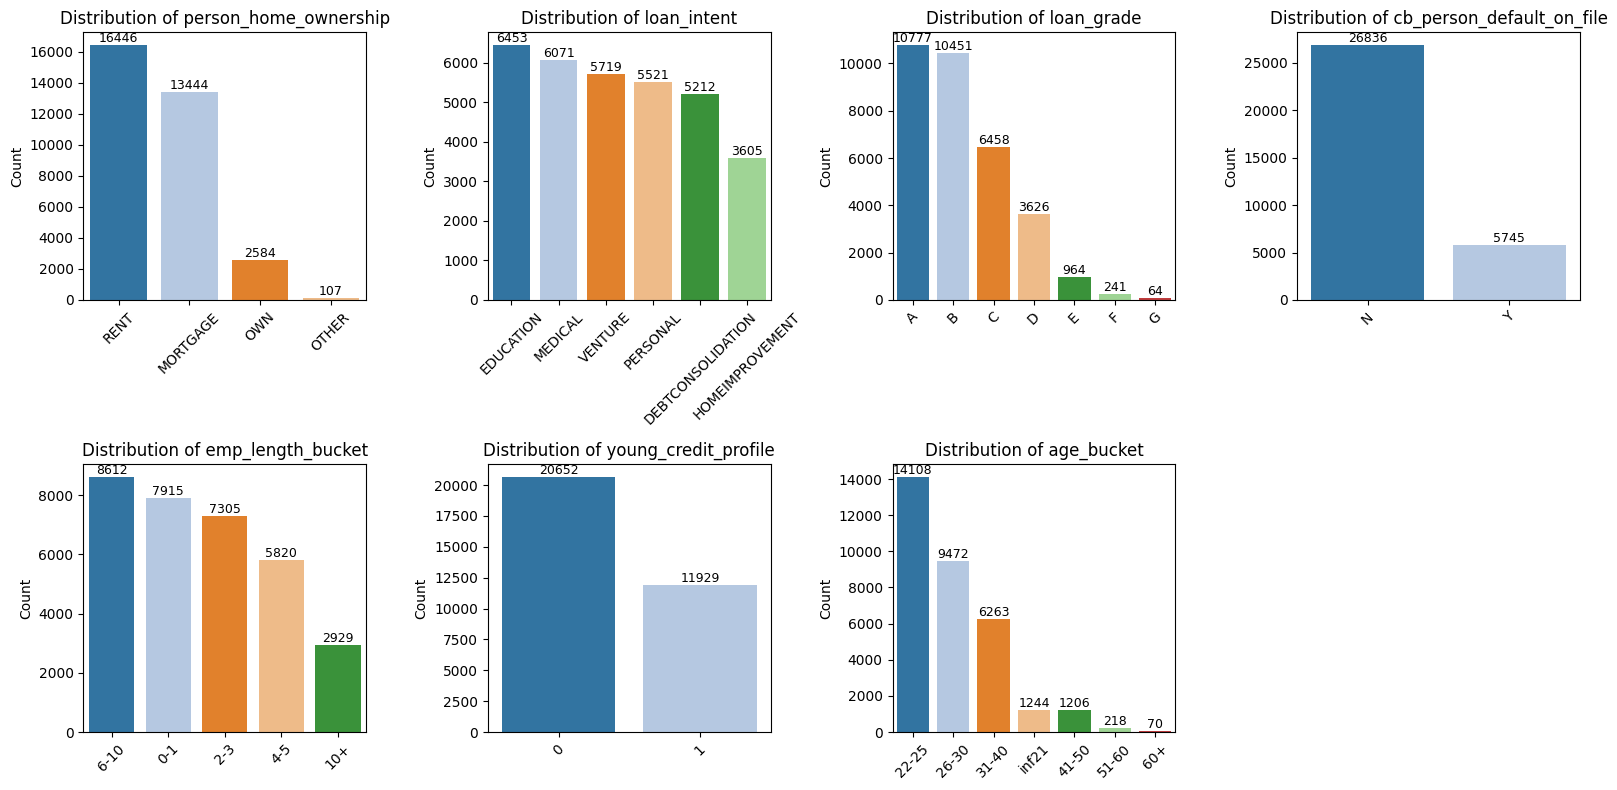

In [17]:
n_plots = len(categorical_features)
n_rows = 2
n_cols = math.ceil(n_plots / n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax = axes[i]
    order = df[col].value_counts().index
    palette = sns.color_palette("tab20", n_colors=len(order))  # distinct colors per modality
    sns.countplot(data=df, x=col, order=order, palette=palette, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    # annotate counts
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9)

# remove any empty subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Continuous Features Box Plots and Histograms

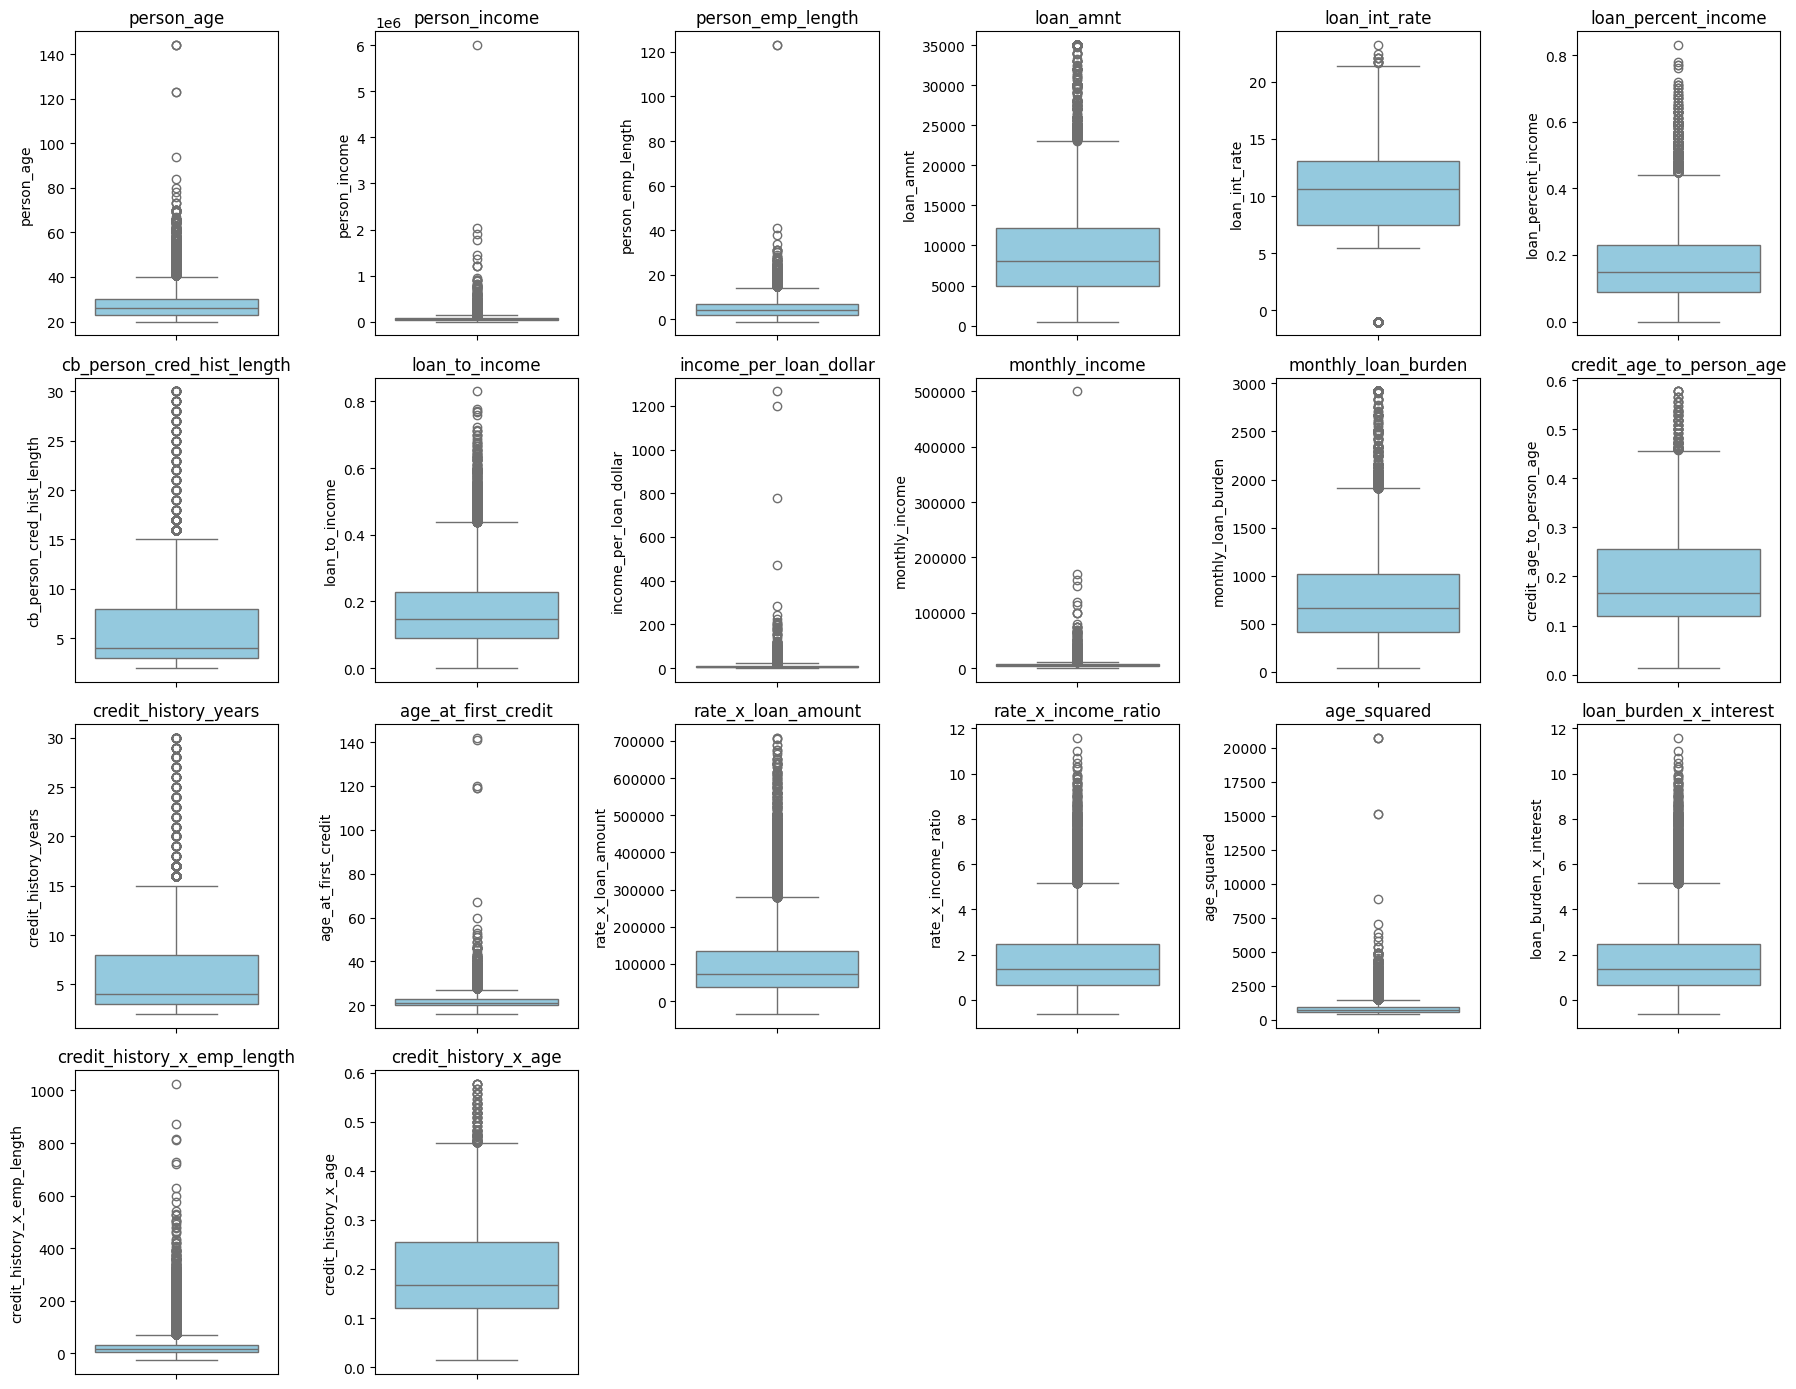

In [18]:
n_plot_features = len(continuous_features)
n_cols = 6
n_rows = math.ceil(n_plot_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, col in enumerate(continuous_features):
    ax = axes[i]
    sns.boxplot(y=df[col], color='skyblue', ax=ax)
    ax.set_title(col)

for j in range(i + 1, n_rows * n_cols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

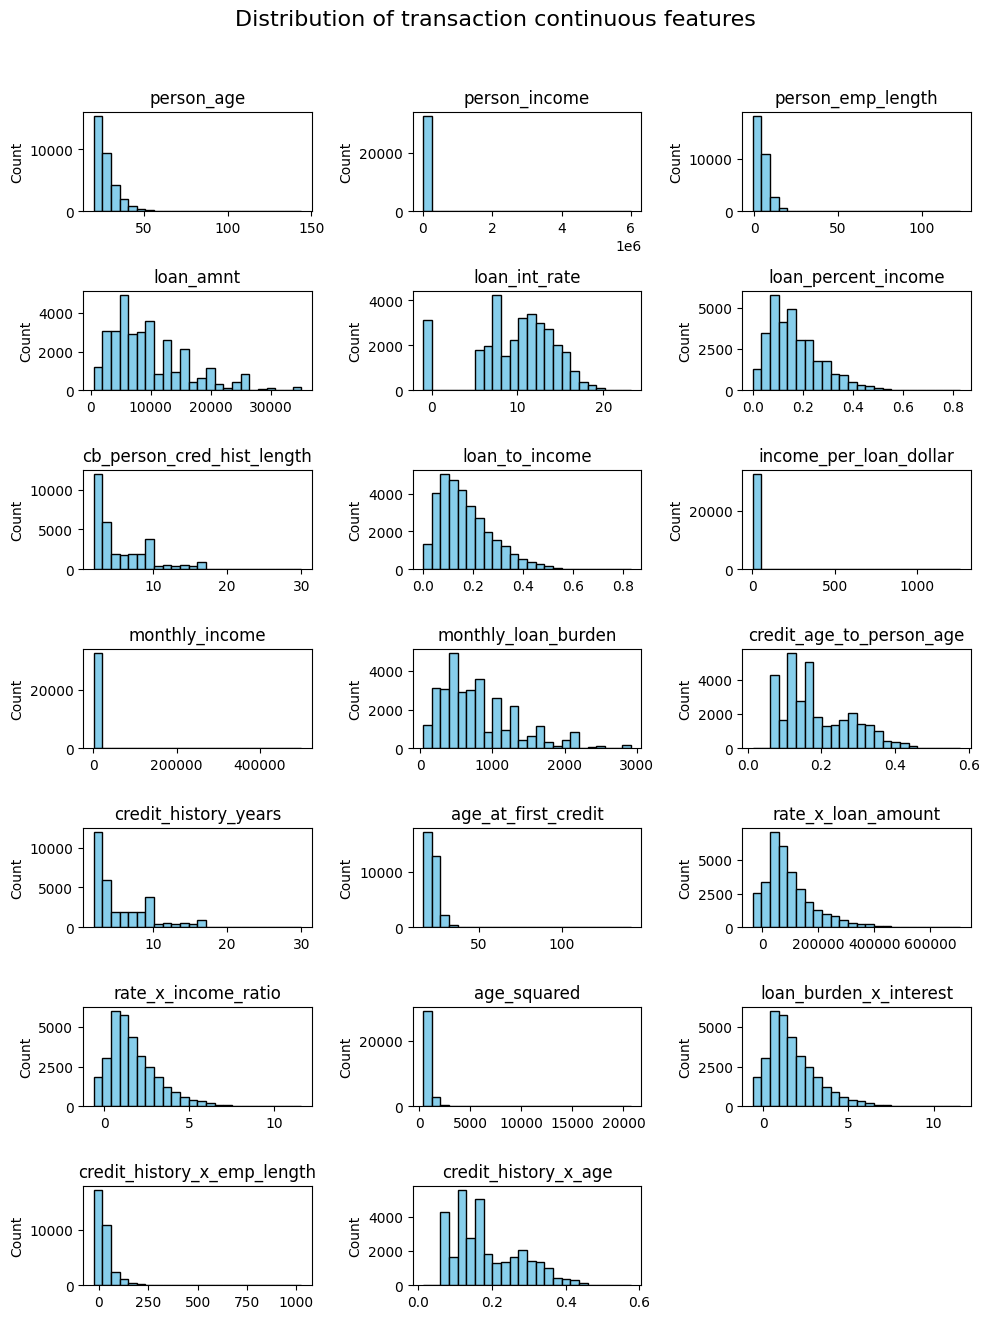

In [19]:
fig, axes = plt.subplots(nrows=n_rows*2, ncols=int(n_cols/2), figsize=(10, 15))
axes = axes.flatten()
for i, col in enumerate(continuous_features):
    # Replace infinite values with NaN, then drop them
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    axes[i].hist(data, bins=24, edgecolor='black', color='skyblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribution of transaction continuous features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Group By Data Analysis

In [20]:
df.groupby(target_variable)[continuous_features].mean().T

loan_status,0,1
person_age,27.807129,27.474676
person_income,70804.361559,49125.652223
person_emp_length,4.825109,3.933737
loan_amnt,9237.464178,10850.502954
loan_int_rate,9.326205,11.786322
loan_percent_income,0.148805,0.246889
cb_person_cred_hist_length,5.837475,5.685003
loan_to_income,0.148730,0.248742
income_per_loan_dollar,10.706168,6.387670
monthly_income,5900.363463,4093.804352


In [21]:
print(categorical_features)

['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'emp_length_bucket', 'young_credit_profile', 'age_bucket']


In [22]:
df.groupby("person_home_ownership")["loan_amnt"].mean()

person_home_ownership
MORTGAGE    10574.460726
OTHER       11074.532710
OWN          9029.943885
RENT         8862.331266
Name: loan_amnt, dtype: float64

In [23]:
df.groupby("loan_intent")["loan_amnt"].mean()

loan_intent
DEBTCONSOLIDATION     9594.886800
EDUCATION             9482.678599
HOMEIMPROVEMENT      10360.520111
MEDICAL               9259.582441
PERSONAL              9573.772867
VENTURE               9583.777758
Name: loan_amnt, dtype: float64

In [24]:
df.pivot_table(values="loan_amnt", index="person_home_ownership", columns="loan_intent")

loan_intent,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
person_home_ownership,,,,,,
MORTGAGE,10537.759516,10542.624667,10773.736358,10603.127854,10407.329060,10641.539839
OTHER,9926.470588,11552.941176,11379.166667,11401.470588,12116.666667,10436.538462
OWN,8194.444444,8917.376894,9361.320755,9383.698157,9006.502242,8865.998728
RENT,8853.255069,8714.256324,10090.710561,8375.430029,8932.149430,8902.506547


# Data Splitting
Splitting the dataset into training and testing sets. Cross-validation will be used during training to evaluate the model's performance and tune hyperparameters while using as much data as possible. The test set will be used for final evaluation of the model's performance.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["loan_status"]),
    df["loan_status"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["loan_status"]
)

# Feature Engineering
No feature selection is done here, but it could have be done using `SelectKBest` or `RFE` (Recursive Feature Elimination) to select the most important features for the model. This can help reduce overfitting and improve model performance, or correlation analysis to remove highly correlated features with graph-based methods.
However, this is not done here as the dataset is already clean and preprocessed.

# Encoding Categorical Variables
Using `OneHotEncoder` to encode categorical variables. This will create new columns for each category in the categorical variables, with a `1` indicating the presence of that category and a `0` indicating its absence. 

In case of too much modalities for a variable, I will reduce the number of modalities by grouping them into a smaller number of categories. 

For example, if there was the country of the person, I would keep the `CATEGORY_SIZE_LIMIT` most frequent countries and group the rest into a single category called `OTHER`. This is to avoid having too many columns in the dataset, which can lead to overfitting and increased computational complexity, even if it can cause some loss of information or add noise to the model.

In [25]:
# printing the number of modalities for each categorical feature in the training set
for feature in categorical_features:
    n_modalities = X_train[feature].nunique()
    print(f"{feature}: {n_modalities} modalities")

person_home_ownership: 4 modalities
loan_intent: 6 modalities
loan_grade: 7 modalities
cb_person_default_on_file: 2 modalities
emp_length_bucket: 5 modalities
young_credit_profile: 2 modalities
age_bucket: 7 modalities


we can directly encode without reducing the number of modalities since there are not too many modalities for each categorical variable in this dataset.

In [27]:
"""
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

new_columns = encoder.get_feature_names_out(categorical_features)

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=new_columns, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=new_columns, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_features), X_train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_features), X_test_encoded_df], axis=1)
"""

"\nencoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)\nX_train_encoded = encoder.fit_transform(X_train[categorical_features])\nX_test_encoded = encoder.transform(X_test[categorical_features])\n\nnew_columns = encoder.get_feature_names_out(categorical_features)\n\nX_train_encoded_df = pd.DataFrame(X_train_encoded, columns=new_columns, index=X_train.index)\nX_test_encoded_df = pd.DataFrame(X_test_encoded, columns=new_columns, index=X_test.index)\n\nX_train = pd.concat([X_train.drop(columns=categorical_features), X_train_encoded_df], axis=1)\nX_test = pd.concat([X_test.drop(columns=categorical_features), X_test_encoded_df], axis=1)\n"

# Scaling Continuous Variables
Using a `StandardScaler` to scale continuous variables. This will standardize the features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that are sensitive to the scale of the input features, such as gradient descent-based algorithms.

In [28]:
# not scaling yet since cross validation will be used and scaling should be done within each fold to avoid data leakage
"""
scaler = StandardScaler()
# X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
# X_test[continuous_features] = scaler.transform(X_test[continuous_features])
"""

'\nscaler = StandardScaler()\n# X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])\n# X_test[continuous_features] = scaler.transform(X_test[continuous_features])\n'

# Imbalanced Dataset Handling (Oversampling/Undersampling)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26064, 27), (6517, 27), (26064,), (6517,))

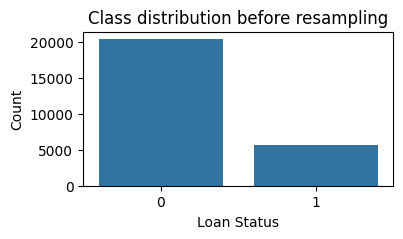

In [30]:
plt.figure(figsize=(4,2))
sns.countplot(x=y_train)
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Class distribution before resampling")
plt.show()

Since we're dealing with a highly imbalanced dataset, we will use `SMOTE` (Synthetic Minority Over-sampling Technique) to upsample the minority class (the non accorded loans) in the training set.
This technique generates synthetic samples from the minority class to balance the dataset with as much modalities from each class.

In [31]:
smote = SMOTE(random_state=RANDOM_STATE)
# not resampling yet since cross validation will be used and resampling should be done within each fold to avoid data leakage
# here just for visuals
X_train_smote, y_train_smote = smote.fit_resample(X_train[continuous_features], y_train) # to avoid issues with non encoded categorical features (so sample not of the same quality as the original dataset)

In [32]:
X_train_smote.shape, X_test.shape, y_train_smote.shape, y_test.shape

((40756, 20), (6517, 27), (40756,), (6517,))

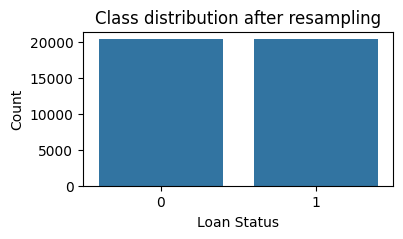

In [33]:
plt.figure(figsize=(4,2))
sns.countplot(x=y_train_smote)
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Class distribution after resampling")
plt.show()

# Model Selection and Hyperparameter Tuning
Using `Optuna` to perform hyperparameter tuning for several models including `RandomForestClassifier`, `XGBClassifier`, and `LGBMClassifier`. The goal is to find the best hyperparameters for each model to maximize the performance on the validation set, before deciding which model to use for feature selection and final evaluation on the test set.

### Evaluation metrics
- **Accuracy**: overall correctness of the model $=\frac{TP + TN}{TP + TN + FP + FN}$ (can't rely on it to give a clue of the model performances)
- **Precision**: correctness of positive predictions $=\frac{TP}{TP + FP}$
- **Recall**: ability to find all positive instances $=\frac{TP}{TP + FN}$
- **F1 Score (Macro)**: harmonic mean of precision and recall, averaged across classes $=2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
- **AUC (Area Under the ROC Curve)**: measures the model's ability to discriminate between positive and negative classes across all possible classification thresholds
    - ROC Curve plots True Positive Rate (Recall) vs False Positive Rate ($\frac{FP}{FP+TN}$)
    - AUC ranges from 0.5 (no discrimination, random guessing) to 1.0 (perfect separation)
    - Higher AUC means the model ranks positive instances higher than negative ones more consistently
    - Particularly useful for imbalanced datasets because it evaluates ranking quality rather than a fixed threshold
- **SHAP**: pour de la `feature_importance` et la feature selection
- **Decile_score**: evaluates model ranking by splitting predictions into deciles and analyzing performance metrics (e.g. conversion rate) per decile

In [26]:
decile_weights = [10, 7, 5, 3, 1, 0, 0, 0, 0, 0]

def decile_score(y_true, y_proba, decile_weights):
    n = len(y_true) #Le nombre de y
    sorted_idx = np.argsort(y_proba)[::-1] # best score first
    y_sorted = y_true[sorted_idx]

    nb_pos = np.sum(y_true)
    decile_size = n // 10
    score = 0.0
    for i, k in enumerate(decile_weights):
        start = i * decile_size
        end = (i + 1) * decile_size if i < 9 else n
        nb_in_decile = np.sum(y_sorted[start:end])
        score += k * (nb_in_decile / nb_pos)
        
    return score / sum(decile_weights)

### Models
- **Logistic Regression:** models the probability of each class using a logistic function, effective for high-dimensional sparse data
- **Linear SVM:** finds the optimal hyperplane that separates classes with maximum margin, efficient for text data
- **SVM (RBF):** uses a radial basis function kernel to capture non-linear decision boundaries
- **Random Forest:** random split the features and build multiple decision trees to improve classification accuracy and control overfitting
- **XGBoost:** an optimized gradient boosting algorithm that builds an ensemble of weak learners (decision trees) to create a strong predictive model
- **Light GBM:** a gradient boosting framework that uses histogram-based algorithms and leaf-wise tree growth for faster training and lower memory usage, especially on large datasets
- **KNN**: classifies based on the majority class among the k-nearest neighbors in the feature space
- **Decision Tree:** a tree-based model that splits the data based on feature values to make predictions
- **SGD Classifier:** uses stochastic gradient descent (taking random subsets of data for each update) to efficiently train linear models on large datasets
- **Naive Bayes:** a probabilistic classifier based on Bayes’ theorem, assuming independence between features
- **MLPClassifier:** a multi-layer perceptron neural network that learns complex non-linear relationships through multiple layers of interconnected neurons


| Algorithm         | Strengths                                                                 | Weaknesses                                                                 | Typical Use Cases                                      |
|-------------------|---------------------------------------------------------------------------|------------------------------------------------------------------------------|--------------------------------------------------------|
| **Logistic Regression** | Fast, interpretable, works well for linearly separable data, outputs calibrated probabilities | Poor with complex non-linear boundaries unless features are engineered     | Baseline models, credit scoring, medical risk prediction |
| **Linear SVM**    | Good for high-dimensional sparse data (e.g., text), robust to overfitting | Only linear boundaries, no probability output by default                    | Text classification, document categorization          |
| **SVM (RBF)**     | Handles non-linear boundaries well, works in high dimensions             | Slow on large datasets, sensitive to hyperparameters                        | Small/medium datasets with complex boundaries         |
| **Random Forest** | Handles non-linearities, robust to noise, works with mixed data types, interpretable feature importance | Can be slower on very large datasets, less interpretable than linear models | Tabular data, feature importance analysis              |
| **XGBoost**       | High accuracy, handles missing values, regularization built-in           | More hyperparameters to tune, can overfit if not tuned                       | Kaggle competitions, tabular data                     |
| **LightGBM**      | Faster than XGBoost on large datasets, good with categorical features    | Can overfit small datasets, sensitive to parameter tuning                    | Large-scale tabular data, real-time scoring            |
| **KNN**           | Simple, no training phase, works well with well-separated classes        | Slow at prediction, sensitive to scaling and irrelevant features             | Small datasets, recommendation systems                 |
| **Decision Tree** | Interpretable, handles mixed data types, fast                            | Prone to overfitting, unstable with small changes in data                     | Simple decision rules, quick prototypes                |
| **SGD Classifier**| Very fast for large sparse datasets, online learning                     | Needs careful tuning of learning rate, sensitive to scaling                   | Text classification, real-time updates                 |
| **Naive Bayes**   | Very fast, works well with high-dimensional sparse data, robust to irrelevant features | Assumes feature independence, poor with correlated features                  | Spam detection, text classification                    |
| **MLPClassifier** | Can model complex non-linear relationships                               | Needs more data, sensitive to scaling, longer training                        | Image recognition, complex tabular patterns            |

General Recommendations : 
- Small dataset, linear-ish problem → Logistic Regression, Linear SVM
- Small dataset, non-linear → SVM (RBF), Random Forest
- **Large tabular dataset → LightGBM, XGBoost, Random Forest**
- High-dimensional sparse data (text) → Linear SVM, Naive Bayes, SGD Classifier
- Need interpretability → Logistic Regression, Decision Tree, Random Forest (with feature importance)
- Real-time / low-latency → LightGBM, Logistic Regression, Naive Bayes
- **Complex patterns, enough data → MLPClassifier, Gradient Boosting methods (LightGBM, XGBoost)**

In [27]:
models = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
    "LGBM": lgb.LGBMClassifier(random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE),
    "SGDClassifier": SGDClassifier(random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB()
}

### Hyperparameter Grids

In [28]:
def xgboost_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5)
    }

def lgbm_params(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", -1, 15),
        "num_leaves": trial.suggest_int("num_leaves", 15, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "min_split_gain": trial.suggest_float("min_split_gain", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "verbosity": -1
    }

def logistic_regression_params(trial):
    solver_penalty = trial.suggest_categorical("solver_penalty",
        [
            ("lbfgs", "l2"),
            ("liblinear", "l1"),
            ("liblinear", "l2"),
            ("saga", "l1"),
            ("saga", "l2"),
            ("saga", "elasticnet"),
        ]
    )
    solver, penalty = solver_penalty

    params = {
        "C": trial.suggest_float("C", 1e-4, 100.0, log=True),
        "solver": solver,
        "penalty": penalty,
        "max_iter": trial.suggest_int("max_iter", 500, 3000, step=500),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    return params


def sgd_classifier_params(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])

    params = {
        "loss": trial.suggest_categorical("loss", ["hinge", "log_loss", "modified_huber", "squared_hinge"]),
        "penalty": penalty,
        "alpha": trial.suggest_float("alpha", 1e-6, 1e-1, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "max_iter": trial.suggest_int("max_iter", 500, 3000, step=500),
        "learning_rate": trial.suggest_categorical("learning_rate", ["optimal", "adaptive"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    if params["learning_rate"] == "adaptive":  # eta0 is relevant for adaptive learning rate
        params["eta0"] = trial.suggest_float("eta0", 1e-5, 1.0, log=True)

    return params

# too lazy to write the rest of the hyperparameter tuning functions for other models, but you can follow the same pattern as above for Logistic Regression, SGD Classifier, Linear SVM, SVM (RBF), Decision Tree, and Naive Bayes.

In [29]:
hyperparameter_grids = {
    "XGBoost": xgboost_params, 
    "LGBM": lgbm_params,
    "LogisticRegression": logistic_regression_params,
    "SGDClassifier": sgd_classifier_params
}
models_to_tune = ["XGBoost", "LGBM", "LogisticRegression", "SGDClassifier"]  # Add other models as needed (+ need to implement their hyperparameter tuning grid functions)

### Hyperparameter Tuning

In [30]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

set_config(transform_output="pandas")
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numerical", numerical_pipeline, continuous_features)
])
pipelines = {model_name: Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", clone(models[model_name]))
]) for model_name in models.keys()}

In [31]:
def get_prediction_scores(model, X):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    return model.decision_function(X)

In [32]:
def evaluate_model(y_true, y_proba, y_pred):
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    return {
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Gini": 2 * roc_auc - 1,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Log Loss": log_loss(y_true, y_proba),
        "Brier": brier_score_loss(y_true, y_proba),
    }

In [33]:
def objective(trial, model_name):
    params = hyperparameter_grids[model_name](trial)

    fold_scores = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = clone(pipelines[model_name])
        model.set_params(**{f"classifier__{k}": v for k, v in params.items()})
        model.fit(X_train_fold, y_train_fold)

        y_val_pred_proba = get_prediction_scores(model, X_val_fold)
        pr_auc = average_precision_score(y_val_fold, y_val_pred_proba)
        fold_scores.append(pr_auc)

    return np.mean(fold_scores)

In [42]:
results = []
studies = {}

for model_name in models_to_tune:
    print(f"Tuning {model_name}...")

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, model_name), n_trials=N_TRIALS)

    studies[model_name] = study
    results.append({
        "model": model_name,
        "best_score": study.best_value,
        "best_params": study.best_params
    })

    print(f"Best {model_name}: {study.best_value:.4f} with params: {study.best_params}")

[I 2026-08-07 00:28:09,912] A new study created in memory with name: no-name-2eacd272-c098-4fb1-a60e-5f536a9e6fd5


Tuning XGBoost...


[I 2026-08-07 00:28:16,867] Trial 0 finished with value: 0.8856008572916437 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.03720949349920521, 'min_child_weight': 15.190667617650714, 'subsample': 0.8493597120880584, 'colsample_bytree': 0.9921329320745325, 'gamma': 1.0556322132867599e-08, 'reg_alpha': 4.273162046784045e-06, 'reg_lambda': 3.637930685645674e-08, 'max_delta_step': 1}. Best is trial 0 with value: 0.8856008572916437.
[I 2026-08-07 00:28:40,693] Trial 1 finished with value: 0.890909628260772 and parameters: {'n_estimators': 750, 'max_depth': 10, 'learning_rate': 0.01419718646757198, 'min_child_weight': 2.6912798172509884, 'subsample': 0.7788742316436063, 'colsample_bytree': 0.9986154168794228, 'gamma': 0.12440328634038769, 'reg_alpha': 0.0564765104993786, 'reg_lambda': 0.0023309443637100583, 'max_delta_step': 1}. Best is trial 1 with value: 0.890909628260772.
[I 2026-08-07 00:29:09,558] Trial 2 finished with value: 0.9026985096549265 and parameters: {

Best XGBoost: 0.9033 with params: {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.14032734093739022, 'min_child_weight': 1.3342095302174777, 'subsample': 0.9649077000916008, 'colsample_bytree': 0.721508175960883, 'gamma': 6.991921934843588e-08, 'reg_alpha': 1.0362049834485443e-06, 'reg_lambda': 0.0026575690594576886, 'max_delta_step': 4}
Tuning LGBM...


[I 2026-08-07 00:35:10,769] Trial 0 finished with value: 0.8974908305919438 and parameters: {'n_estimators': 650, 'learning_rate': 0.17869581120827102, 'max_depth': -1, 'num_leaves': 56, 'min_child_samples': 23, 'min_split_gain': 0.00025142559924147973, 'subsample': 0.9770606618908865, 'colsample_bytree': 0.7441734183863588, 'reg_alpha': 0.00496435006982017, 'reg_lambda': 1.012038097453592e-06}. Best is trial 0 with value: 0.8974908305919438.
[I 2026-08-07 00:36:55,849] Trial 1 finished with value: 0.8981681945027464 and parameters: {'n_estimators': 1050, 'learning_rate': 0.040165006228131565, 'max_depth': 14, 'num_leaves': 128, 'min_child_samples': 46, 'min_split_gain': 0.0029912479865103537, 'subsample': 0.8269187701763647, 'colsample_bytree': 0.6172577686393058, 'reg_alpha': 5.198561647154239e-05, 'reg_lambda': 0.5124079552611186}. Best is trial 1 with value: 0.8981681945027464.
[I 2026-08-07 00:37:28,356] Trial 2 finished with value: 0.897763480385254 and parameters: {'n_estimators

Best LGBM: 0.9029 with params: {'n_estimators': 650, 'learning_rate': 0.13083453735902584, 'max_depth': 4, 'num_leaves': 78, 'min_child_samples': 15, 'min_split_gain': 2.7711786140377895e-06, 'subsample': 0.6453221963247836, 'colsample_bytree': 0.9497488672592579, 'reg_alpha': 0.23053805272492756, 'reg_lambda': 1.2610382437539605e-05}
Tuning LogisticRegression...


[I 2026-08-07 00:47:44,553] Trial 0 finished with value: 0.5619606208679576 and parameters: {'solver_penalty': ('liblinear', 'l1'), 'C': 0.0006872931738484384, 'max_iter': 2000, 'class_weight': None}. Best is trial 0 with value: 0.5619606208679576.
/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('lbfgs', 'l2') which is of type tuple.
  warnings.warn(message)
/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('liblinear', 'l1') which is of type tuple.
  warnings.warn(message)
/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a 

Best LogisticRegression: 0.7403 with params: {'solver_penalty': ('liblinear', 'l2'), 'C': 14.954456743232726, 'max_iter': 2500, 'class_weight': None}
Tuning SGDClassifier...


[I 2026-08-07 00:59:09,624] Trial 0 finished with value: 0.7343414757538589 and parameters: {'penalty': 'elasticnet', 'loss': 'squared_hinge', 'alpha': 8.370627538344622e-06, 'l1_ratio': 0.42416239796562716, 'max_iter': 2500, 'learning_rate': 'adaptive', 'class_weight': 'balanced', 'eta0': 0.0008036043841853874}. Best is trial 0 with value: 0.7343414757538589.
[I 2026-08-07 00:59:16,140] Trial 1 finished with value: 0.5042690381548318 and parameters: {'penalty': 'l2', 'loss': 'squared_hinge', 'alpha': 0.000894743038289979, 'l1_ratio': 0.45458482859013705, 'max_iter': 3000, 'learning_rate': 'optimal', 'class_weight': None}. Best is trial 0 with value: 0.7343414757538589.
[I 2026-08-07 00:59:18,643] Trial 2 finished with value: 0.7286986035799835 and parameters: {'penalty': 'l2', 'loss': 'modified_huber', 'alpha': 1.2229314436457924e-05, 'l1_ratio': 0.01597950535713699, 'max_iter': 3000, 'learning_rate': 'adaptive', 'class_weight': 'balanced', 'eta0': 0.00613712554377081}. Best is trial 

Best SGDClassifier: 0.7397 with params: {'penalty': 'l2', 'loss': 'log_loss', 'alpha': 2.0763084503292776e-06, 'l1_ratio': 0.977768841914579, 'max_iter': 2500, 'learning_rate': 'adaptive', 'class_weight': 'balanced', 'eta0': 0.034689150402000955}


### Hyperparameter Tuning Outputs plots
- `plot_optimization_history(study)`: tell whether the refinement worked, with still things to gain 
- `plot_param_importances(study)`: each cluster is a region, so it will tell which params matter locally, often different from the global importance
- `plot_intermediate_values(study)`: show progress of each trial over iterations

In [43]:
for model_name, study in studies.items():
    print(f"Best {model_name}: {study.best_value:.4f} with params: {study.best_params}")
    plot_optimization_history(study)
    plot_param_importances(study)
    plot_intermediate_values(study)

Best XGBoost: 0.9033 with params: {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.14032734093739022, 'min_child_weight': 1.3342095302174777, 'subsample': 0.9649077000916008, 'colsample_bytree': 0.721508175960883, 'gamma': 6.991921934843588e-08, 'reg_alpha': 1.0362049834485443e-06, 'reg_lambda': 0.0026575690594576886, 'max_delta_step': 4}


[W 2026-08-07 01:00:55,256] You need to set up the pruning feature to utilize `plot_intermediate_values()`
[W 2026-08-07 01:00:55,382] You need to set up the pruning feature to utilize `plot_intermediate_values()`


Best LGBM: 0.9029 with params: {'n_estimators': 650, 'learning_rate': 0.13083453735902584, 'max_depth': 4, 'num_leaves': 78, 'min_child_samples': 15, 'min_split_gain': 2.7711786140377895e-06, 'subsample': 0.6453221963247836, 'colsample_bytree': 0.9497488672592579, 'reg_alpha': 0.23053805272492756, 'reg_lambda': 1.2610382437539605e-05}
Best LogisticRegression: 0.7403 with params: {'solver_penalty': ('liblinear', 'l2'), 'C': 14.954456743232726, 'max_iter': 2500, 'class_weight': None}


[W 2026-08-07 01:00:55,483] You need to set up the pruning feature to utilize `plot_intermediate_values()`


Best SGDClassifier: 0.7397 with params: {'penalty': 'l2', 'loss': 'log_loss', 'alpha': 2.0763084503292776e-06, 'l1_ratio': 0.977768841914579, 'max_iter': 2500, 'learning_rate': 'adaptive', 'class_weight': 'balanced', 'eta0': 0.034689150402000955}


[W 2026-08-07 01:00:55,791] You need to set up the pruning feature to utilize `plot_intermediate_values()`


### Model Selection

In [44]:
df_results = pd.DataFrame(results).sort_values(by="best_score", ascending=False)
print(df_results)

                model  best_score  \
0             XGBoost    0.903305   
1                LGBM    0.902927   
2  LogisticRegression    0.740267   
3       SGDClassifier    0.739650   

                                                                                                                                                                                                                                                                                                                  best_params  
0  {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.14032734093739022, 'min_child_weight': 1.3342095302174777, 'subsample': 0.9649077000916008, 'colsample_bytree': 0.721508175960883, 'gamma': 6.991921934843588e-08, 'reg_alpha': 1.0362049834485443e-06, 'reg_lambda': 0.0026575690594576886, 'max_delta_step': 4}  
1           {'n_estimators': 650, 'learning_rate': 0.13083453735902584, 'max_depth': 4, 'num_leaves': 78, 'min_child_samples': 15, 'min_split_gain': 2.7711786140377895e-06, '

In [ ]:
"""
df_results = pd.DataFrame({
    "model": ["XGBoost", "LGBM", "LogisticRegression", "SGDClassifier"],
    "best_score": [0.903305, 0.902927, 0.740267, 0.739650],
    "best_params": [
        {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.14032734093739022, 'min_child_weight': 1.3342095302174777, 'subsample': 0.9649077000916008, 'colsample_bytree': 0.721508175960883, 'gamma': 6.991921934843588e-08, 'reg_alpha': 1.0362049834485443e-06, 'reg_lambda': 0.0026575690594576886, 'max_delta_step': 4},
        {'n_estimators': 650, 'learning_rate': 0.13083453735902584, 'max_depth': 4, 'num_leaves': 78, 'min_child_samples': 15, 'min_split_gain': 2.7711786140377895e-06, 'subsample': 0.6453221963247836, 'colsample_bytree': 0.9497488672592579, 'reg_alpha': 0.23053805272492756, 'reg_lambda': 1.2610382437539605e-05},
        {'solver_penalty': ('liblinear', 'l2'), 'C': 14.954456743232726, 'max_iter': 2500, 'class_weight': None},
        {'penalty': 'l2', 'loss': 'log_loss', 'alpha': 2.0763084503292776e-06, 'l1_ratio': 0.977768841914579, 'max_iter': 2500, 'learning_rate': 'adaptive', 'class_weight': 'balanced', 'eta0': 0.034689150402000955}
    ]
})
"""

In [35]:
print("Best model:", df_results.iloc[0]["model"])
print("Best model params:", df_results.iloc[0]["best_params"])

Best model: XGBoost
Best model params: {'n_estimators': 650, 'max_depth': 5, 'learning_rate': 0.14032734093739022, 'min_child_weight': 1.3342095302174777, 'subsample': 0.9649077000916008, 'colsample_bytree': 0.721508175960883, 'gamma': 6.991921934843588e-08, 'reg_alpha': 1.0362049834485443e-06, 'reg_lambda': 0.0026575690594576886, 'max_delta_step': 4}


In [36]:
# retraining the whole selected model 
best_model_name = df_results.iloc[0]["model"]
best_model_params = df_results.iloc[0]["best_params"]

model = clone(pipelines[best_model_name])
model.set_params(**{f"classifier__{k}": v for k, v in best_model_params.items()})

model.fit(X_train, y_train) # Since using StratifiedKFold, we can fit the model on the entire training set after hyperparameter tuning
y_proba = get_prediction_scores(model, X_test)
y_pred = (y_proba >= PROBA_THRESHOLD).astype(int)

In [37]:
full_model_metrics = evaluate_model(y_test, y_proba, y_pred)

### First evaluation of the Final Model
The goal is to assess the full performance of the model before the dimentionnality reduction and feature selection, to have a baseline to compare with after the feature selection, see if we loose too much information and performance, or if we can keep the same performance with less features.

Confusion Matrix: 

      0     1
0  5048    47
1   354  1068


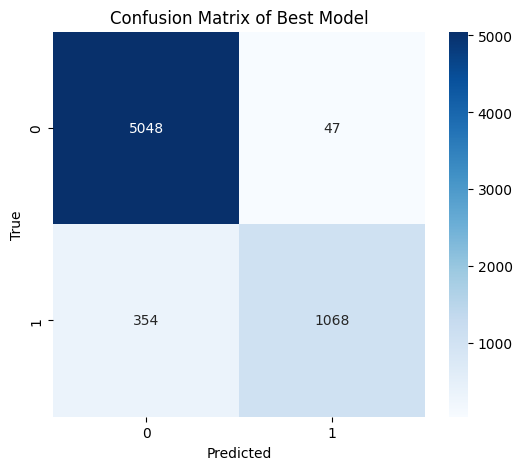

In [38]:
print("Confusion Matrix: \n")
classes = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=classes, columns=classes))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix of Best Model")
plt.show()

In [39]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

recall = recall_score(y_test, y_pred, average="macro")
print("Recall: ", recall)

precision = precision_score(y_test, y_pred, average="macro")
print("Precision: ", precision)

f1score = f1_score(y_test, y_pred, average="macro")
print("F1-score: ", f1score)

Classification Report: 

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.75      0.84      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.87      0.90      6517
weighted avg       0.94      0.94      0.94      6517

Accuracy:  0.9384686205309192
Recall:  0.8709150610965495
Precision:  0.9461581244614601
F1-score:  0.9018689537551676


AUC:  0.8709150610965495
ROC-AUC Curve: 



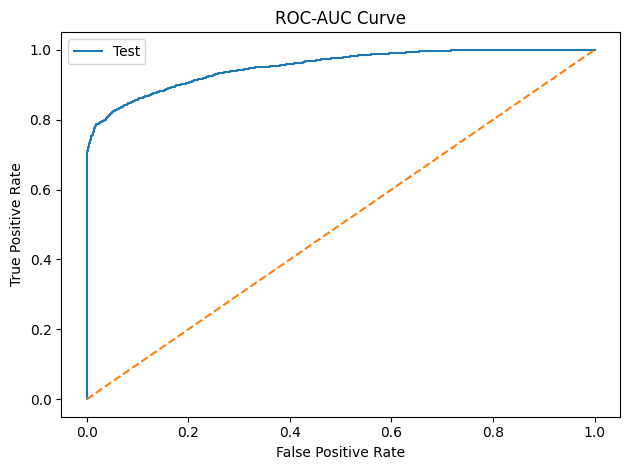

In [40]:
auc = roc_auc_score(y_test, y_pred, average="macro")
print("AUC: ", auc)

df_test_results = pd.DataFrame([y_pred, y_test, y_proba], index=["prediction", "true_value", "proba_1"]).T
fpr, tpr, _ = roc_curve(df_test_results.true_value, df_test_results.proba_1, pos_label=1) # , average="macro")

print("ROC-AUC Curve: \n")
plt.plot(fpr, tpr, label='Test')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
gini = 2 * roc_auc_score(y_test, y_pred) - 1
print("Gini: ", gini)

Gini:  0.741830122193099


# Feature Importance and Selection 
The goal is to retain the most important features for the selectedmodel, keeping the most relevant ones discarding those that can be considered as noise.
We can use `SHAP` (SHapley Additive exPlanations) to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from cooperative game theory and their related extensions. Permutation importance is another method to evaluate feature importance by measuring the increase in the model's prediction error after permuting the feature's values, which breaks the relationship between the feature and the target.

In [42]:
def get_original_feature(feature_name):
    feature_name = feature_name.split("__", 1)[-1]

    for col in categorical_features + continuous_features:
        if feature_name == col or feature_name.startswith(col + "_"):
            return col

    return feature_name

In [43]:
shap_importances = []
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {fold + 1}/{N_FOLDS}")
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Fresh pipeline for this fold
    model = clone(pipelines[best_model_name])
    model.set_params(**{f"classifier__{k}": v for k, v in best_model_params.items()})
    model.fit(X_train_fold, y_train_fold)

    # SHAP samples
    X_background = X_train_fold.sample(n=BACKGROUND_SAMPLE_SIZE, random_state=RANDOM_STATE)  # background dataset for SHAP
    X_explain = X_val_fold.sample(n=EXPLAIN_SAMPLE_SIZE, random_state=RANDOM_STATE)  # data to explain with SHAP

    # Transform using this fold's fitted preprocessor
    preprocessor = model.named_steps["preprocessor"]
    feature_names = preprocessor.get_feature_names_out()
    X_background_transformed = pd.DataFrame(preprocessor.transform(X_background), columns=feature_names, index=X_background.index)
    X_explain_transformed = pd.DataFrame(preprocessor.transform(X_explain), columns=feature_names, index=X_explain.index)

    # SHAP values computation
    classifier = model.named_steps["classifier"]
    if classifier.__class__.__name__ in ["RandomForestClassifier", "XGBClassifier", "LGBMClassifier"]:
        try:
            explainer = shap.TreeExplainer(classifier, data=X_background_transformed, feature_perturbation="interventional")
        except Exception as e:
            explainer = shap.Explainer(classifier, data=X_background_transformed, feature_perturbation="interventional")
        shap_values = explainer(X_explain_transformed, check_additivity=False)
    else:
        explainer = shap.PartitionExplainer(lambda x: classifier.predict_proba(x)[:, 1], data=X_background_transformed)
        shap_values = explainer(X_explain_transformed)

    # One-hot SHAP importance
    fold_importance = pd.DataFrame({"feature": feature_names, "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)})

    # Map encoded features back to original features
    fold_importance["original_feature"] = fold_importance["feature"].apply(get_original_feature)

    # Sum one-hot components into original feature
    fold_original_importance = fold_importance.groupby("original_feature", as_index=False)["mean_abs_shap"].sum()
    fold_original_importance["fold"] = fold

    shap_importances.append(fold_original_importance)

Fold 1/5


 99%|===================| 4939/5000 [00:57<00:00]        

Fold 2/5


 98%|===================| 4917/5000 [00:56<00:00]        

Fold 3/5


 99%|===================| 4973/5000 [00:56<00:00]        

Fold 4/5


 99%|===================| 4969/5000 [00:56<00:00]        

Fold 5/5


 99%|===================| 4959/5000 [00:55<00:00]        

In [44]:
shap_df = pd.concat(shap_importances, ignore_index=True)
feature_importance = (
    shap_df
    .groupby("original_feature")["mean_abs_shap"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
)

# Relative importance
feature_importance["importance_pct"] = feature_importance["mean"] / feature_importance["mean"].sum()

# Cumulative importance
feature_importance["cumulative_importance_pct"] = feature_importance["importance_pct"].cumsum()

# Print 
feature_importance

,mean,std,importance_pct,cumulative_importance_pct
original_feature,,,,
loan_to_income,2.739794,0.172967,0.196109,0.196109
loan_percent_income,2.267519,0.396089,0.162304,0.358413
person_home_ownership,1.473528,0.251891,0.105472,0.463886
loan_grade,1.398361,0.026597,0.100092,0.563978
loan_intent,1.258384,0.050678,0.090073,0.654050
person_income,0.875733,0.034633,0.062683,0.716733
income_per_loan_dollar,0.562528,0.176601,0.040265,0.756998
loan_int_rate,0.473305,0.065076,0.033878,0.790876
monthly_income,0.255045,0.019690,0.018256,0.809132


In [71]:
selected_features = feature_importance.loc[feature_importance["cumulative_importance_pct"] <= KEEP_PCT].index.tolist()

# Add the first feature that pushes cumulative importance over KEEP_PCT
if len(selected_features) < len(feature_importance):
    selected_features.append(feature_importance.index[len(selected_features)])

print(f"Selected {len(selected_features)} / {len(feature_importance)} features ({len(selected_features) / len(feature_importance):.1%})")
print(f"SHAP importance retained: {feature_importance.loc[selected_features, 'importance_pct'].sum():.1%}")

for feature in selected_features:
    print(f"- {feature}")

Selected 15 / 27 features (55.6%)
SHAP importance retained: 90.6%
- loan_to_income
- loan_percent_income
- person_home_ownership
- loan_grade
- loan_intent
- person_income
- income_per_loan_dollar
- loan_int_rate
- monthly_income
- person_age
- rate_x_loan_amount
- emp_length_bucket
- person_emp_length
- credit_history_x_emp_length
- loan_amnt


In [72]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((26064, 27), (6517, 27), (26064,), (6517,))

In [73]:
# Drop unselected features from X_train
X_train_reduced = X_train[selected_features].copy()
X_test_reduced = X_test[selected_features].copy()

In [74]:
X_train_reduced.shape, X_test_reduced.shape, y_train.shape, y_test.shape

((26064, 15), (6517, 15), (26064,), (6517,))

In [75]:
# Update feature lists
categorical_features_reduced = [feature for feature in categorical_features if feature in selected_features]
continuous_features_reduced = [feature for feature in continuous_features if feature in selected_features]

# Training of the Final Model

In [76]:
set_config(transform_output="pandas")
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features_reduced),
    ("numerical", numerical_pipeline, continuous_features_reduced)
])
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", clone(models[best_model_name]))
])

In [77]:
model = clone(final_pipeline)
model.set_params(**{f"classifier__{k}": v for k, v in best_model_params.items()})
model.fit(X_train_reduced, y_train)

y_proba = get_prediction_scores(model, X_test_reduced)
y_pred = (y_proba >= PROBA_THRESHOLD).astype(int)

# Saving the Final Model

In [78]:
OUTPUT_DIR = Path("data/modern_credit_risk_model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
final_model_path = OUTPUT_DIR / f"model.pkl"

In [79]:
joblib.dump(model, final_model_path)
# no need to save encoders and scalers separately since they are part of the pipeline and will be saved with the model
# Save inference configuration
joblib.dump(
    {
        "threshold": PROBA_THRESHOLD,
        "selected_features": selected_features,
        "categorical_features": categorical_features,
        "continuous_features": continuous_features,
    },
    OUTPUT_DIR / f"metadata.pkl"
)

['data/modern_credit_risk_model/metadata.pkl']

# Evaluation of the Final Model

### Comparison between the Full Model and the Reduced Model

In [80]:
reduced_model_metrics = evaluate_model(y_test, y_proba, y_pred)

In [81]:
comparison = pd.DataFrame({"Full model": full_model_metrics, "Reduced model": reduced_model_metrics})
comparison["Difference"] = comparison["Reduced model"] - comparison["Full model"]
comparison["Relative change (%)"] = comparison["Difference"] / comparison["Full model"] * 100
comparison

,Full model,Reduced model,Difference,Relative change (%)
ROC-AUC,0.951769,0.953992,0.002223,0.233553
PR-AUC,0.911151,0.913891,0.002740,0.300725
Gini,0.903539,0.907985,0.004446,0.492040
Accuracy,0.938469,0.938469,0.000000,0.000000
Precision,0.957848,0.950574,-0.007274,-0.759394
Recall,0.751055,0.757384,0.006329,0.842697
F1,0.841939,0.843053,0.001114,0.132259
Log Loss,0.181312,0.176987,-0.004326,-2.385806
Brier,0.050085,0.049299,-0.000785,-1.567713


### Confusion Matrix

Confusion Matrix: 

      0     1
0  5039    56
1   345  1077


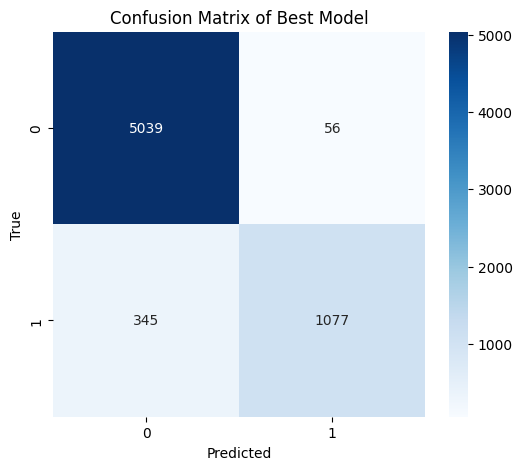

In [82]:
print("Confusion Matrix: \n")
classes = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=classes, columns=classes))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix of Best Model")
plt.show()

### Classification Report

In [83]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

recall = recall_score(y_test, y_pred, average="macro")
print("Recall: ", recall)

precision = precision_score(y_test, y_pred, average="macro")
print("Precision: ", precision)

f1score = f1_score(y_test, y_pred, average="macro")
print("F1-score: ", f1score)

Classification Report: 

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      5095
           1       0.95      0.76      0.84      1422

    accuracy                           0.94      6517
   macro avg       0.94      0.87      0.90      6517
weighted avg       0.94      0.94      0.94      6517

Accuracy:  0.9384686205309192
Recall:  0.8731963992165729
Precision:  0.9432474731445792
F1-score:  0.9023929136812439


### ROC-AUC Curve + Gini Coefficient

AUC:  0.8731963992165729
ROC-AUC Curve: 



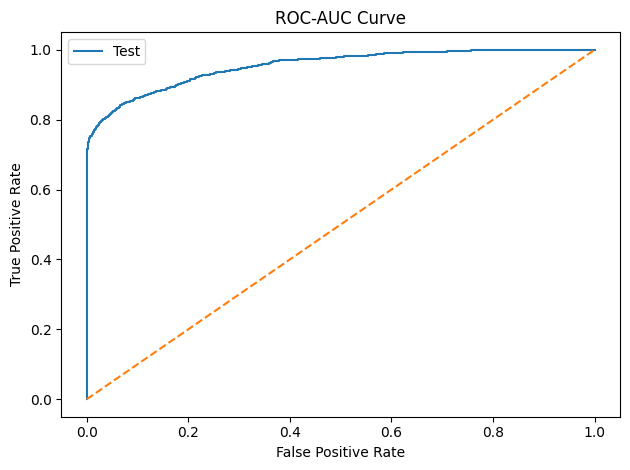

In [84]:
auc = roc_auc_score(y_test, y_pred, average="macro")
print("AUC: ", auc)

df_test_results = pd.DataFrame([y_pred, y_test, y_proba], index=["prediction", "true_value", "proba_1"]).T
fpr, tpr, _ = roc_curve(df_test_results.true_value, df_test_results.proba_1, pos_label=1) # , average="macro")

print("ROC-AUC Curve: \n")
plt.plot(fpr, tpr, label='Test')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
gini = 2 * roc_auc_score(y_test, y_pred) - 1
print("Gini: ", gini)

Gini:  0.7463927984331458


### Calibration Curve

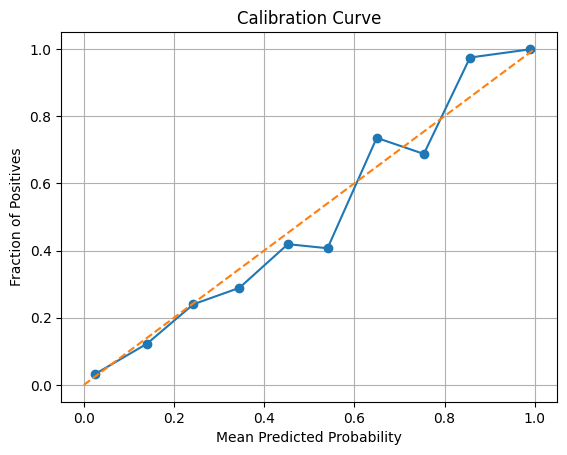

In [86]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.grid()
plt.show()

### Lift Curve 

In [87]:
df_results = pd.DataFrame([y_pred, y_test, y_proba], index=["prediction", "true_value", "proba_1"]).T
df_results = df_results.sort_values(by="proba_1", ascending=False).reset_index(drop=True)
df_results["decile"] = 10 - pd.qcut(df_results["proba_1"].rank(method="first"), q=10, labels=False)

# Number of elements and number of target found in each decile
df_results["cumul_elements"] = (df_results.index + 1) / len(df_results)
df_results["cumul_target_found"] = df_results["true_value"].cumsum() / df_results["true_value"].sum()

In [88]:
# Table of deciles with number of target found and number of elements in each decile
table_deciles = df_results.groupby("decile").agg(
    nb_target_found=("true_value", "sum"), nb_elements=("true_value", "count"),
    min_proba=("proba_1", "min"), max_proba=("proba_1", "max")
).sort_values("decile")

# Rate of capture of the target variable in each decile
table_deciles["capture_rate"] = table_deciles["nb_target_found"].cumsum() / table_deciles["nb_target_found"].sum()
table_deciles["capture_rate_pct"] = table_deciles["capture_rate"].map(lambda x: f"{100*x:.1f}%")


# Rate of elements in each decile
table_deciles["rate_elements"] = table_deciles["nb_elements"] / table_deciles["nb_elements"].sum()
table_deciles["rate_elements_pct"] = table_deciles["rate_elements"].map(lambda x: f"{100*x:.1f}%")

# Proba intervals for each decile
table_deciles["intervalle_proba"] = table_deciles.apply(lambda row: f"[{row['min_proba']:.3f} ; {row['max_proba']:.3f}]", axis=1)
print("\nTable of deciles with capture rates and probability intervals: \n")
table_deciles[["nb_elements", "rate_elements_pct", "nb_target_found", "capture_rate_pct", "intervalle_proba"]]


Table of deciles with capture rates and probability intervals: 



,nb_elements,rate_elements_pct,nb_target_found,capture_rate_pct,intervalle_proba
decile,,,,,
1,652,10.0%,652.0,45.9%,[0.995 ; 1.000]
2,652,10.0%,488.0,80.2%,[0.323 ; 0.995]
3,651,10.0%,114.0,88.2%,[0.131 ; 0.321]
4,652,10.0%,72.0,93.2%,[0.071 ; 0.131]
5,651,10.0%,49.0,96.7%,[0.040 ; 0.071]
6,652,10.0%,17.0,97.9%,[0.022 ; 0.040]
7,652,10.0%,19.0,99.2%,[0.011 ; 0.022]
8,651,10.0%,7.0,99.7%,[0.004 ; 0.011]
9,652,10.0%,4.0,100.0%,[0.001 ; 0.004]


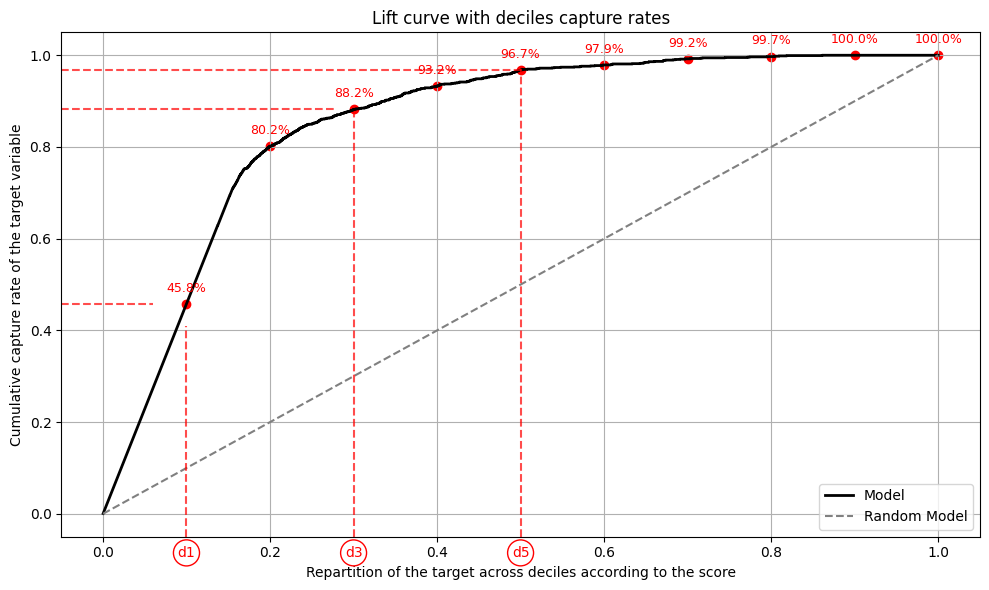

In [89]:
plt.figure(figsize=(10, 6))
plt.plot(df_results["cumul_elements"], df_results["cumul_target_found"], label="Model", color="black", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")
# Show the points and the labels of the data, and highlight the 1st, 3rd and 5th deciles on the graph (targeting the top 10% and 50% : key deciles to evaluate often)

for i in range(1, 11):
    index_end_decile = int(i * len(df_results) / 10) - 1
    x = df_results.loc[index_end_decile, "cumul_elements"]
    y = df_results.loc[index_end_decile, "cumul_target_found"]
    plt.scatter(x, y, color="red")
    plt.text(x, y + 0.020, f"{y*100:.1f}%", ha="center", va="bottom", fontsize=9, color="red")
    if i in [1, 3, 5]:
        plt.axvline(x=x, linestyle="--", color="red", ymax=y-0.04, alpha=0.7)
        plt.axhline(y=y, linestyle="--", color="red", xmax=x, alpha=0.7)
        plt.text(x, -0.07, f"d{i}", ha="center", va="top", fontsize=10, color="red", bbox=dict(boxstyle="circle", edgecolor="red", facecolor="white"))

plt.xlabel("Repartition of the target across deciles according to the score")
plt.ylabel("Cumulative capture rate of the target variable")
plt.title("Lift curve with deciles capture rates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Probability Distribution of the Predictions

In [90]:
decile_probability = df_results.groupby("decile")["proba_1"].agg(proba_min="min", proba_max="max")
df_deciles = decile_probability.reset_index()
df_deciles["version"] = best_model_name
df_deciles

,decile,proba_min,proba_max,version
0,1,9.948172e-01,1.000000,XGBoost
1,2,3.227949e-01,0.994816,XGBoost
2,3,1.308225e-01,0.320733,XGBoost
3,4,7.129346e-02,0.130766,XGBoost
4,5,3.965369e-02,0.071268,XGBoost
5,6,2.204382e-02,0.039652,XGBoost
6,7,1.102682e-02,0.022044,XGBoost
7,8,4.262683e-03,0.011014,XGBoost
8,9,8.421061e-04,0.004261,XGBoost
9,10,1.552300e-07,0.000835,XGBoost


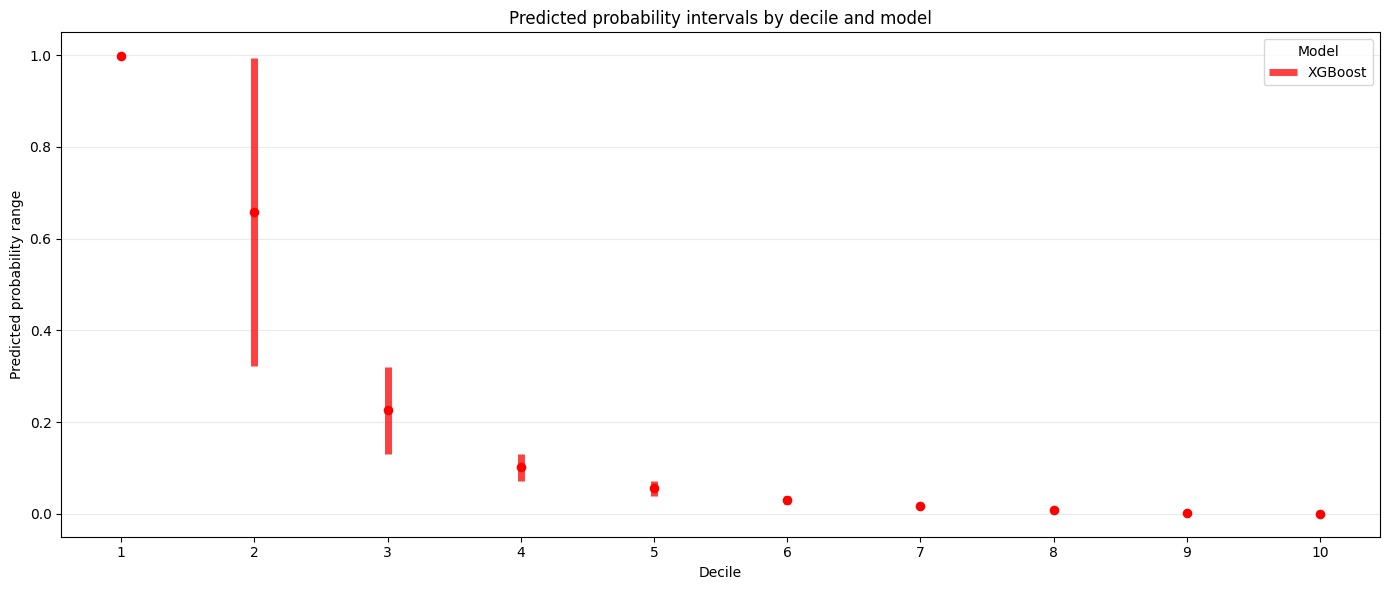

In [91]:
colors = ["red"]

plt.figure(figsize=(14, 6))
versions = df_deciles["version"].unique()
x = np.arange(1, 11) # deciles
width = 0.18

for i, version in enumerate(versions):
    df_v = df_deciles[df_deciles["version"] == version].sort_values("decile")
    x_shifted = x + (i - (len(versions)-1)/2) * width
    plt.vlines(x_shifted, df_v["proba_min"], df_v["proba_max"], color=colors[i % len(colors)], linewidth=5, alpha=0.75, label=version)
    proba_mid = (df_v["proba_min"] + df_v["proba_max"]) / 2 # Central marker (midpoint)
    plt.scatter(x_shifted, proba_mid, color=colors[i % len(colors)], s=35, zorder=3)
    
plt.xticks(x)
plt.xlabel("Decile")
plt.ylabel("Predicted probability range")
plt.title("Predicted probability intervals by decile and model")
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# SHAP Explanation

In [ ]:
X_background = shap.sample(X_train, min(BACKGROUND_SAMPLE_SIZE, len(X_train)), random_state=RANDOM_STATE)

X_pos = X_test[y_test == 1]
X_neg = X_test[y_test == 0]
X_explain = pd.concat([
    X_pos.sample(min(int(EXPLAIN_SAMPLE_SIZE/2), len(X_pos)), random_state=RANDOM_STATE),
    X_neg.sample(min(int(EXPLAIN_SAMPLE_SIZE/2), len(X_neg)), random_state=RANDOM_STATE)
])

# Transform using the fitted preprocessor
preprocessor = model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
X_background_transformed = pd.DataFrame(preprocessor.transform(X_background), columns=feature_names, index=X_background.index)
X_explain_transformed = pd.DataFrame(preprocessor.transform(X_explain), columns=feature_names, index=X_explain.index)

# SHAP values computation
classifier = model.named_steps["classifier"]
if classifier.__class__.__name__ in ["RandomForestClassifier", "XGBClassifier", "LGBMClassifier"]:
    explainer = shap.TreeExplainer(classifier, data=X_background_transformed, feature_perturbation="interventional")
    shap_values = explainer(X_explain_transformed, check_additivity=False)
else:
    explainer = shap.PartitionExplainer(lambda x: classifier.predict_proba(x)[:, 1], data=X_background_transformed)
    shap_values = explainer(X_explain_transformed)

y_explain = y_test.loc[X_explain.index]

 98%|===================| 3844/3922 [00:43<00:00]        

In [93]:
TOP_N_PLOT = 30

**Plot bar**: displays mean absolute SHAP values per feature, **ranking global feature importance**

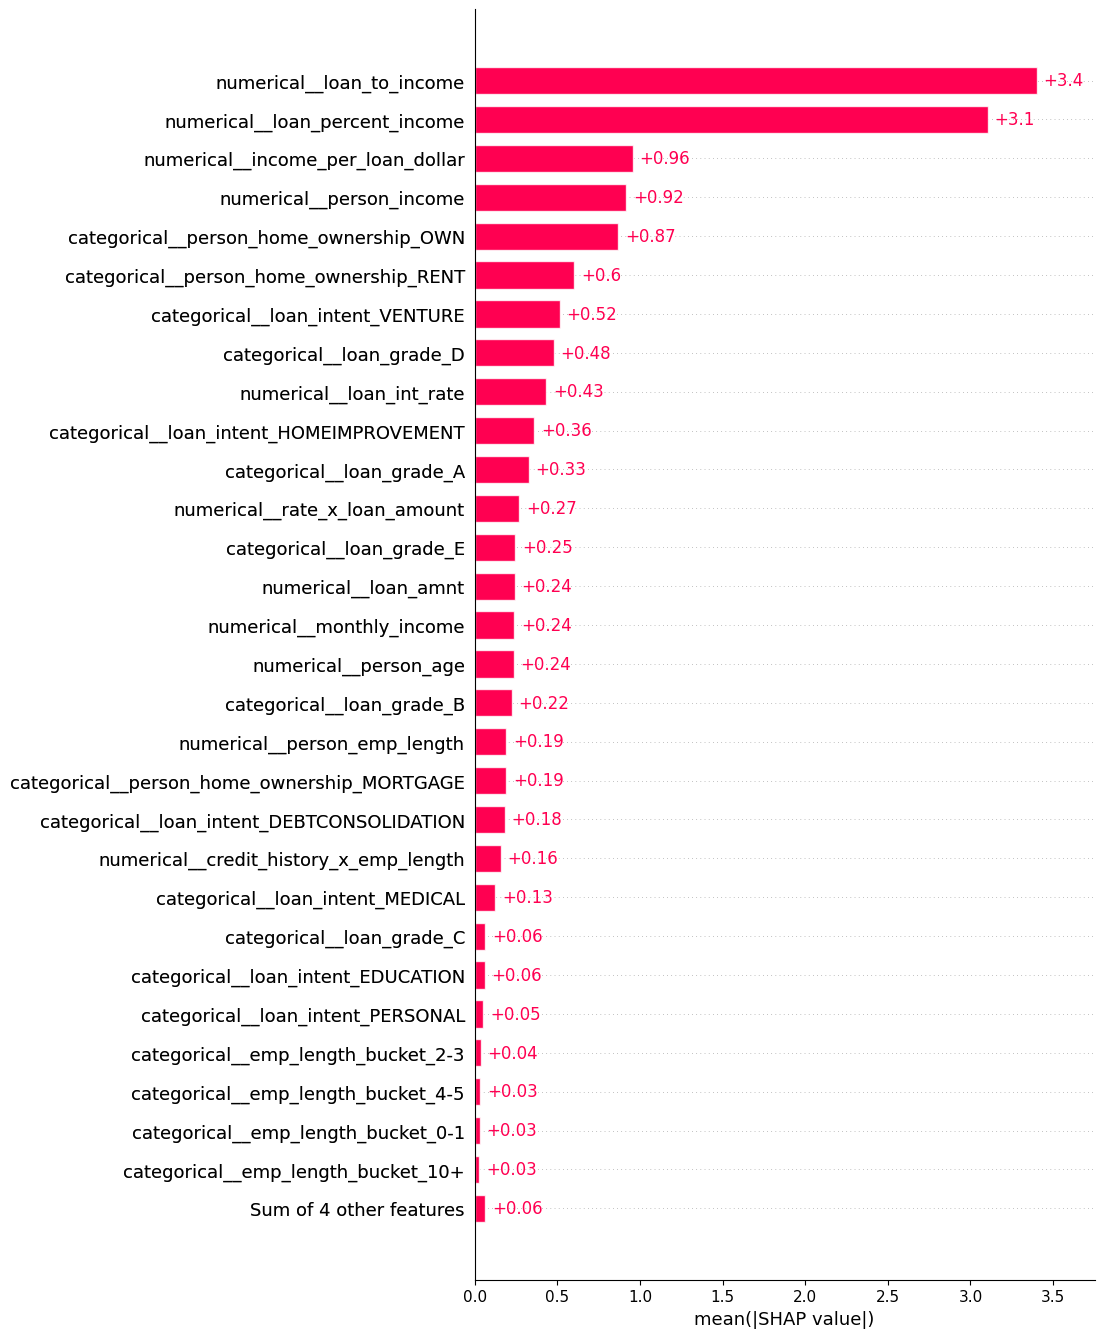

In [94]:
shap.plots.bar(shap_values, max_display=TOP_N_PLOT)

**Cohort Plot Bar:** multiple-bar plot with one bar type for each of the cohorts represented by the explanation objects

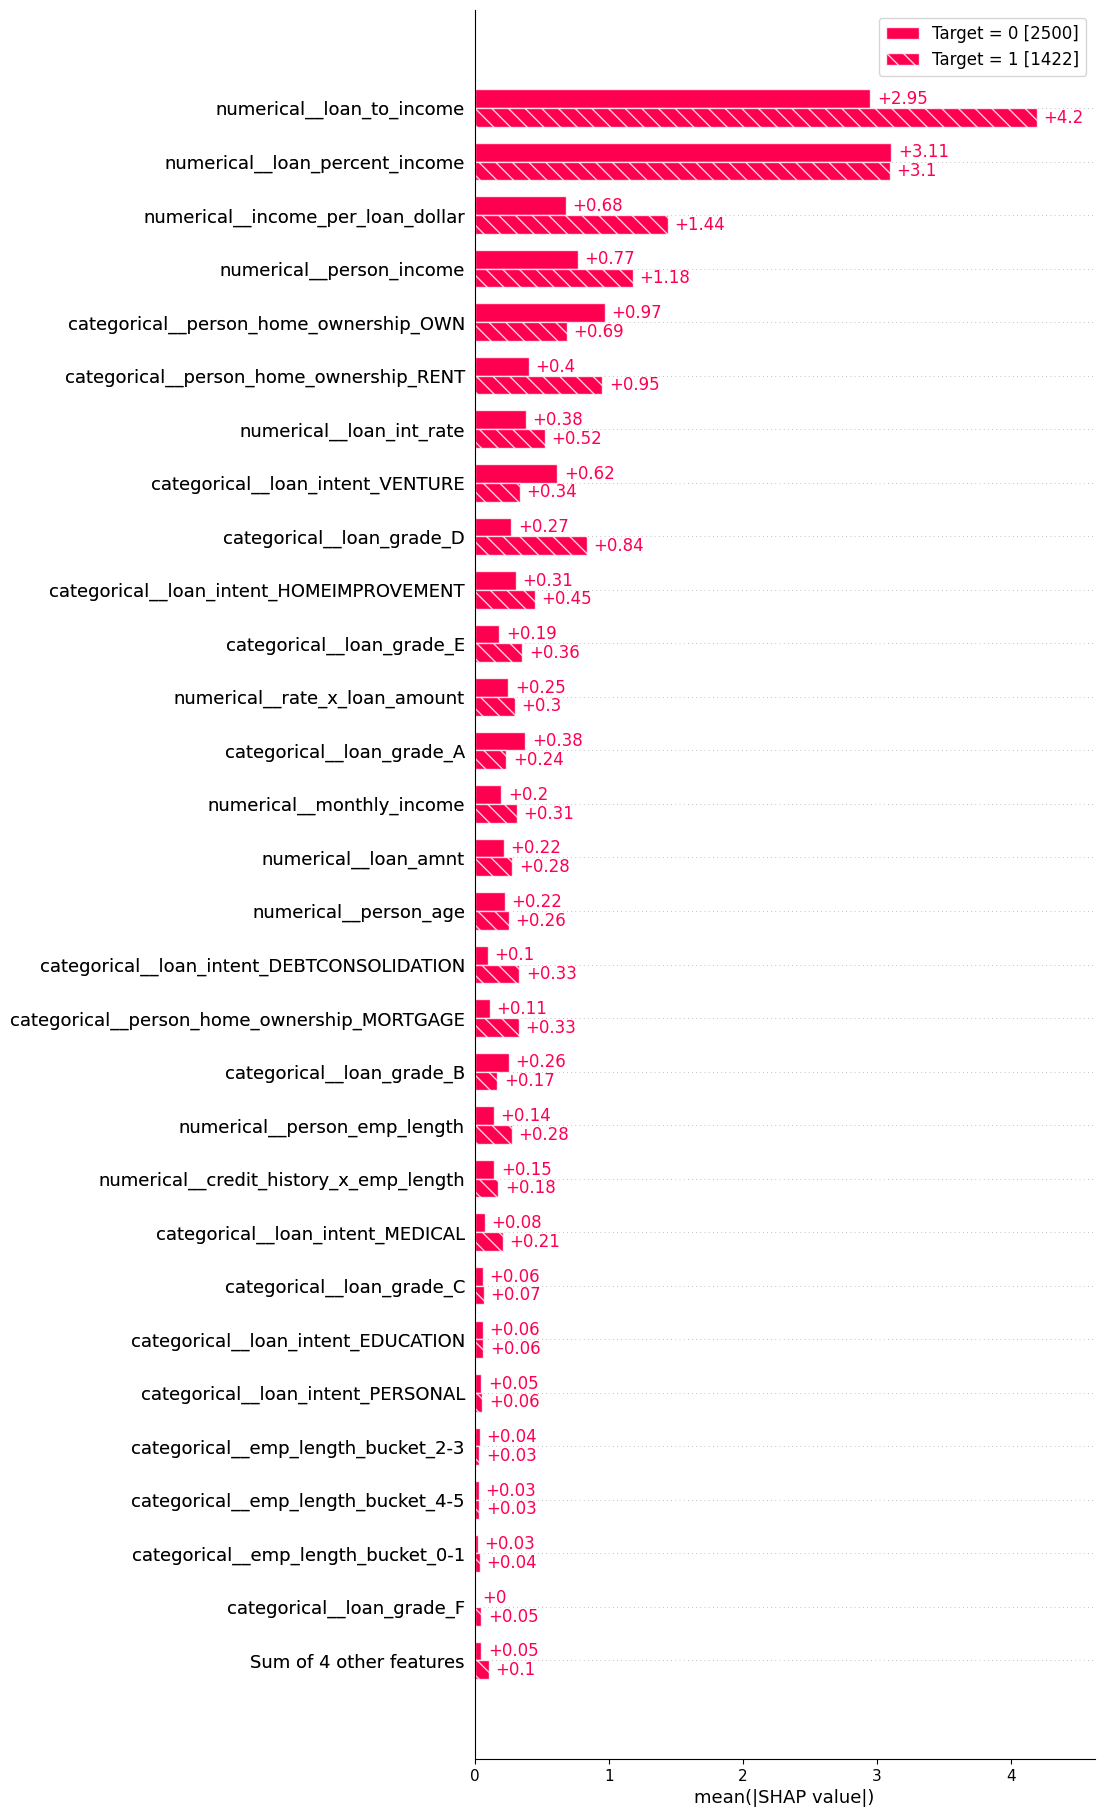

In [97]:
cohorts = ["Target = 1" if y == 1 else "Target = 0" for y in y_explain]
shap.plots.bar(shap_values.cohorts(cohorts).abs.mean(0), max_display=TOP_N_PLOT)

**Summary Plot (Beeswarm):** shows individual SHAP values for each feature and instance

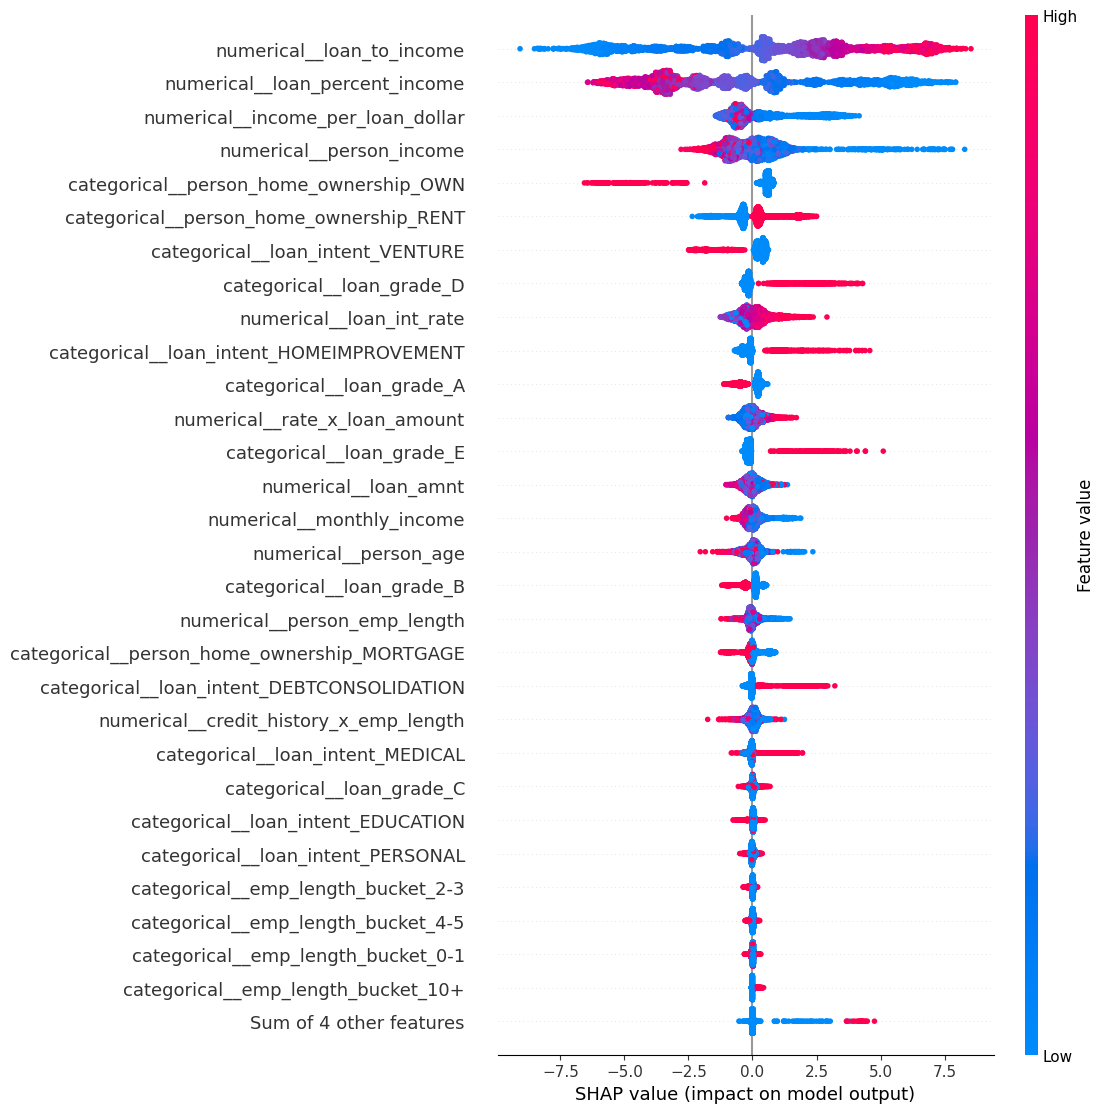

In [98]:
shap.plots.beeswarm(shap_values, max_display=TOP_N_PLOT)

**Summary Plot (Violin):** displays the distribution of SHAP values per feature as violin plots, stacked by importance (sum of absolute SHAP values)

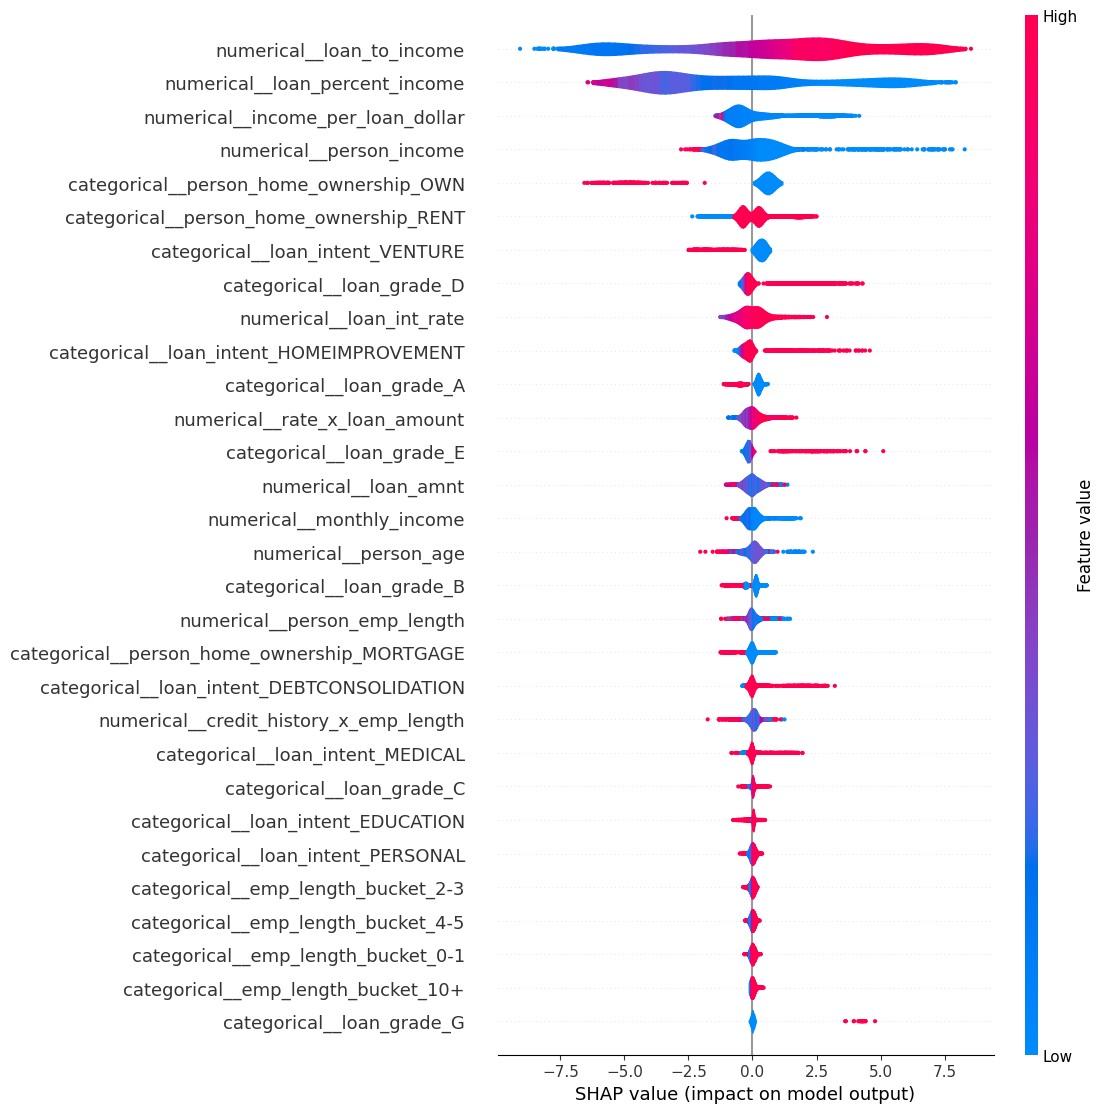

In [99]:
shap.plots.violin(shap_values, X_explain_transformed, max_display=TOP_N_PLOT)

One case for each of the 4 spots of the confusion matrix, so we can explain true predictions, false positive/negative etc ...
- **Local Plot Bar:** local feature importance plot, where the bars are the SHAP values for each feature: only one line there, so the SHAP contributions of this single line
- **Waterfall Plot:** designed to explain the contribution of each feature to a single prediction
- **Decision Plot:** show how complex models arrive at their predictions (how models make decisions)

In [100]:
y_proba_explain = get_prediction_scores(model, X_explain)
y_pred_explain = (y_proba_explain >= PROBA_THRESHOLD).astype(int)

# TN, FP, FN, TP on explain subset
tn_idx = np.where((y_explain == 0) & (y_pred_explain == 0))[0]
fp_idx = np.where((y_explain == 0) & (y_pred_explain == 1))[0]
fn_idx = np.where((y_explain == 1) & (y_pred_explain == 0))[0]
tp_idx = np.where((y_explain == 1) & (y_pred_explain == 1))[0]

tn_idx, fp_idx, fn_idx, tp_idx = tn_idx[0], fp_idx[0], fn_idx[0], tp_idx[0]  # Get the first index of each case
cases = [
    ("True Negative", tn_idx),
    ("False Positive", fp_idx),
    ("False Negative", fn_idx),
    ("True Positive", tp_idx),
]

/var/folders/8j/y46wyjvx641clg_t_cq0ggfc0000gn/T/ipykernel_93859/1551351062.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


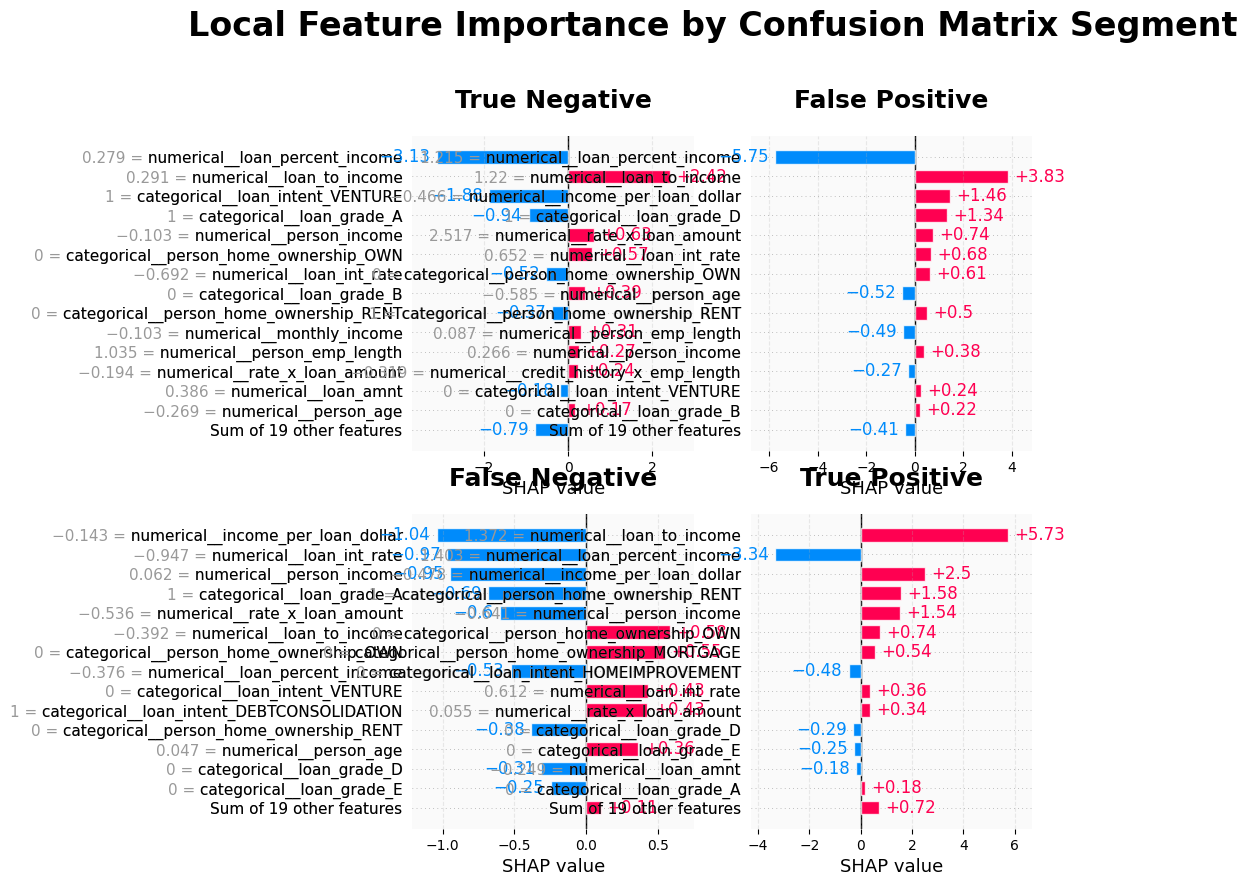

In [101]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
positions = [
    (0, 0), (0, 1),
    (1, 0), (1, 1),
]

for (title, idx), (i, j) in zip(cases, positions):
    ax = axes[i, j]
    plt.sca(ax)
    shap.plots.bar(shap_values[idx], max_display=TOP_N_PLOT//2, show=False)
    ax.set_title(title, fontsize=18, fontweight="bold", color="black", pad=20)
    ax.set_facecolor("#FAFAFA")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle("Local Feature Importance by Confusion Matrix Segment", fontsize=24, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

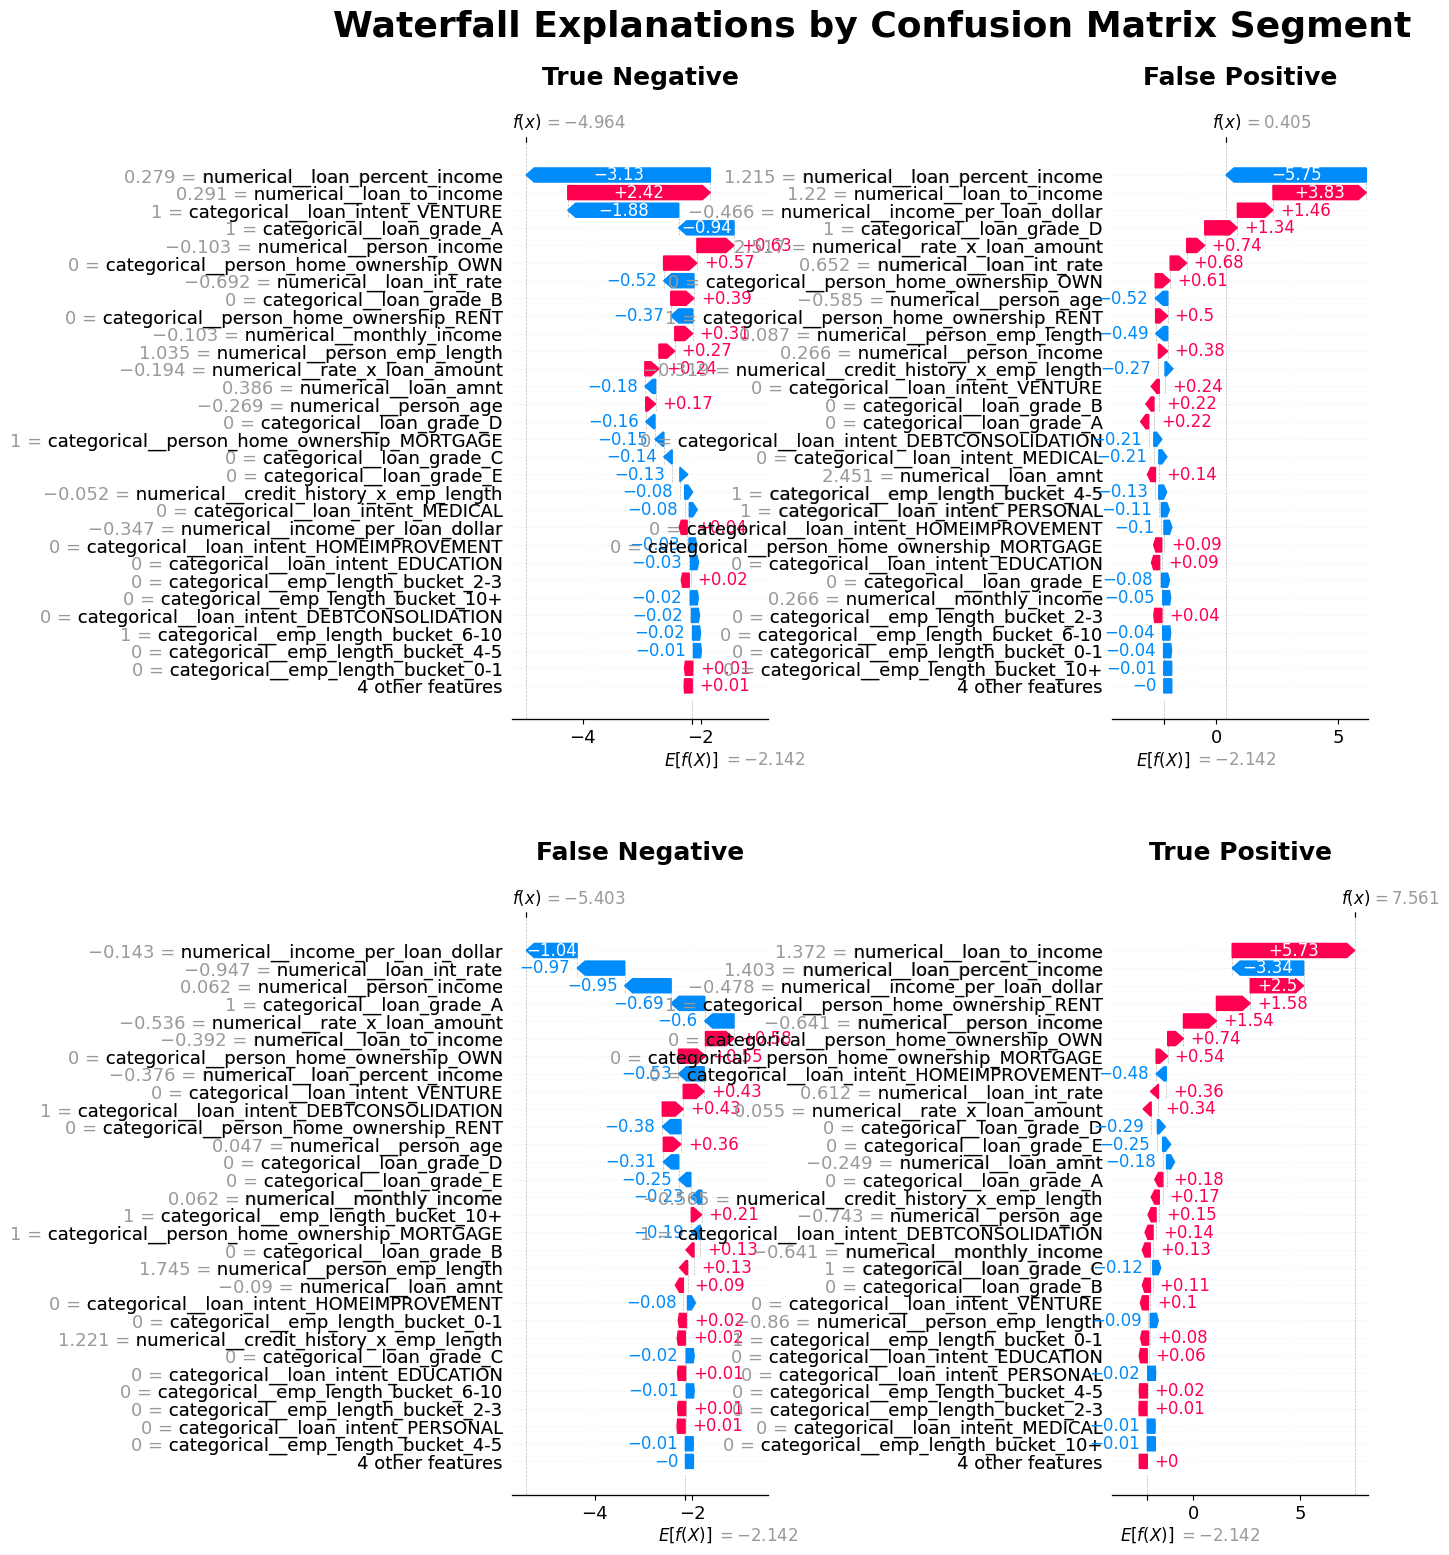

In [102]:
fig = plt.figure(figsize=(30, 34))

# Manual axes positions: [left, bottom, width, height]
axes_positions = [
    [0.05, 0.55, 0.32, 0.35],  # top-left
    [0.80, 0.55, 0.32, 0.35],  # top-right
    [0.05, 0.08, 0.32, 0.35],  # bottom-left
    [0.80, 0.08, 0.32, 0.35],  # bottom-right
]
for (title, idx), pos in zip(cases, axes_positions):
    ax = fig.add_axes(pos)
    plt.sca(ax)
    shap.plots.waterfall(shap_values[idx], max_display=TOP_N_PLOT, show=False)
    ax.set_title(title, fontsize=18, fontweight="bold", color="black", pad=20)

fig.suptitle("Waterfall Explanations by Confusion Matrix Segment", fontsize=26, fontweight="bold", y=0.98)
plt.show()

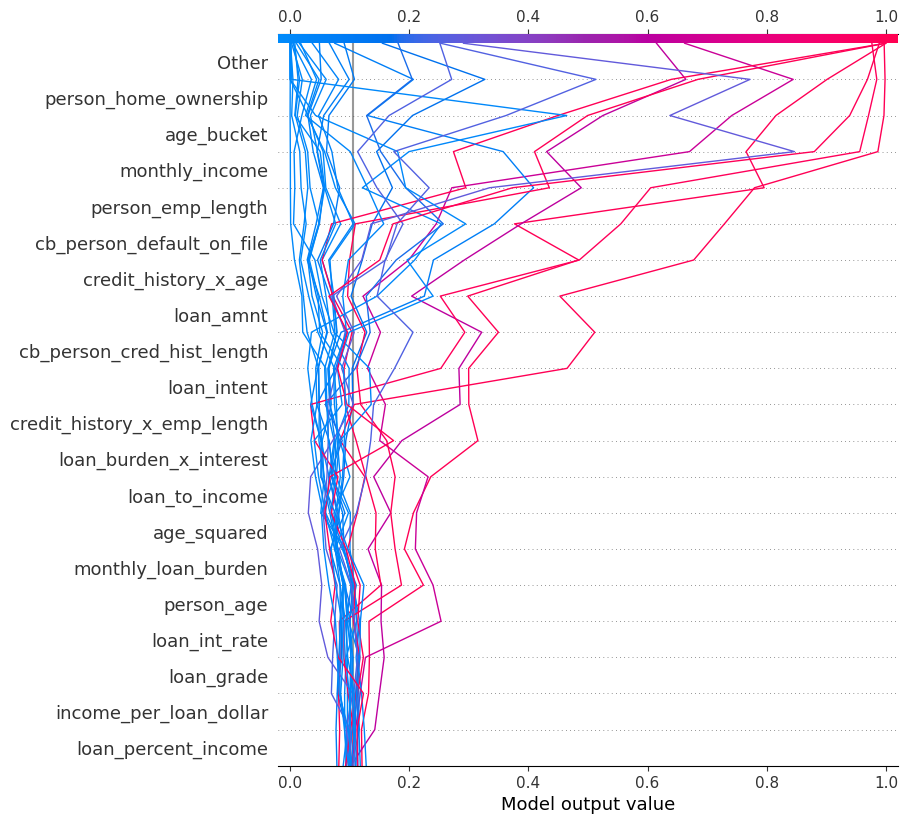

In [103]:
col_idx = [X_explain.columns.get_loc(col) for col in X_explain.columns]
shap_vals_subset = shap_values.values[:, col_idx]
X_subset = X_explain

other_idx = [i for i in range(shap_values.values.shape[1]) if i not in col_idx]
other_contrib = shap_values.values[:, other_idx].sum(axis=1).reshape(-1, 1)
shap_vals_grouped = np.hstack([shap_vals_subset, other_contrib])

X_grouped = X_explain.copy()
X_grouped["Other"] = 0

idx = np.random.choice(len(X_grouped), size=TOP_N_PLOT, replace=False)
shap.decision_plot(explainer.expected_value, shap_vals_grouped[idx], X_grouped.iloc[idx], link="logit")